<a href="https://colab.research.google.com/github/lifan149/notes/blob/main/fastai/Practical-Deep-Learning-for-Coders/dlfc_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

根据[fastbook第四节](https://github.com/fastai/fastbook/blob/master/04_mnist_basics.ipynb)记录的笔记

In [1]:
#hide
! [ -e /content ] && pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.0 MB/s eta 0:00:00
Mounted at /content/gdrive


In [2]:
#hide
from fastai.vision.all import *
from fastbook import *

# 将 Matplotlib 中所有后续图像绘制（特别是使用 imshow() 函数显示图像）的默认颜色映射设置为灰度模式（从白到黑）

# cmap 是 colormap 的缩写，中文可以翻译为颜色映射或色图。颜色映射是一种将数值数据映射到颜色的方式。
# 在 Matplotlib 中，当你绘制图像、热力图或其他需要颜色来表示数值的数据时，cmap 参数就会起作用

# 'Greys' 是一种预定义的颜色映射方案。它表示从白色到黑色的灰度颜色映射。
# 具体来说，当你在 imshow() 函数（用于显示图像）或其他接受 cmap 参数的函数中使用它时：
# 数值越小（例如，图像像素值越低），颜色越接近白色。
# 数值越大（例如，图像像素值越高），颜色越接近黑色。
matplotlib.rc('image', cmap='Greys')

根据教程尝试创建一个可以将任何图像分类为 3 或 7 的模型。下载一个仅包含这些数字图像的 MNIST 示例

In [4]:
# fastai 库中用于下载并解压数据集的常用方法
path = untar_data(URLs.MNIST_SAMPLE)

In [5]:
# 将 Path 类（而不是 Path 的一个实例）的一个类属性 BASE_PATH 设置为变量 path 所指向的值
Path.BASE_PATH = path

通过 fastai 添加的方法 ls 来查看这个目录中的内容。此方法返回一个名为 L 的特殊 fastai 类的对象，该类具有与 Python 内置列表相同的功能，以及更多功能。它的一个方便的功能是，在打印时，它会在列出项目本身之前显示项目计数（如果超过 10 个项目，它只显示前几个项目）：

In [6]:
# path 属于pathlib.PosixPath 类，实际上PosixPath没有ls()方法
# 是在 fastcore.xtras 中定义的，通过猴子补丁，它被“附加”到了 PosixPath 类上，所以你可以像调用 PosixPath 的原生方法一样调用它
# 可以通过helo(path.ls)查看
path.ls()

(#3) [Path('labels.csv'),Path('train'),Path('valid')]

MNIST 数据集遵循机器学习数据集的常见布局：训练集和验证集（和/或测试集）的单独文件夹。

In [7]:
# 查看训练集的内容
(path/'train').ls()

(#2) [Path('train/3'),Path('train/7')]

有一个 3 的文件夹和一个 7 的文件夹。在机器学习术语中，我们说“3”和“7”是此数据集中的标签 （或目标）

In [8]:
threes = (path/'train'/'3').ls().sorted()
sevens = (path/'train'/'7').ls().sorted()
threes

(#6131) [Path('train/3/10.png'),Path('train/3/10000.png'),Path('train/3/10011.png'),Path('train/3/10031.png'),Path('train/3/10034.png'),Path('train/3/10042.png'),Path('train/3/10052.png'),Path('train/3/1007.png'),Path('train/3/10074.png'),Path('train/3/10091.png'),Path('train/3/10093.png'),Path('train/3/10097.png'),Path('train/3/10099.png'),Path('train/3/10116.png'),Path('train/3/10125.png'),Path('train/3/10137.png'),Path('train/3/10141.png'),Path('train/3/10144.png'),Path('train/3/10155.png'),Path('train/3/10161.png')...]

一张手写数字 3 的图片，取自手写数字 MNIST 数据集

In [9]:
im3_path = threes[1]
im3 = Image.open(im3_path)
im3

在计算机中，一切都表示为数字。要查看构成此图像的数字，我们必须将其转换为 NumPy 数组或 PyTorch 张量 。

**本质上，NumPy 数组（ndarray）和 PyTorch 张量（Tensor）在核心结构上都是多维数组**

**PyTorch 张量在 NumPy 数组的基础上，额外提供了 GPU 加速和自动求导的功能，使其更适合深度学习任务。**

将图像的一部分转为NumPy 数组

4:10 (对于行): 选取从索引为 4 的行开始，直到但不包括索引为 10 的行。换句话说，它会选择索引为 4, 5, 6, 7, 8, 9 的这 6 行。

4:10 (对于列): 这表示选取从索引为 4 的列开始，直到但不包括索引为 10 的列。同样地，它会选择索引为 4, 5, 6, 7, 8, 9 的这 6 列。

NumPy 从上到下、从左到右编制索引，因此此部分位于图像的左上角

In [10]:
array(im3)[4:10,4:10]

array([[  0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,  29],
       [  0,   0,   0,  48, 166, 224],
       [  0,  93, 244, 249, 253, 187],
       [  0, 107, 253, 253, 230,  48],
       [  0,   3,  20,  20,  15,   0]], dtype=uint8)

 PyTorch 张量也是如此

In [11]:
tensor(im3)[4:10,4:10]

tensor([[  0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,  29],
        [  0,   0,   0,  48, 166, 224],
        [  0,  93, 244, 249, 253, 187],
        [  0, 107, 253, 253, 230,  48],
        [  0,   3,  20,  20,  15,   0]], dtype=torch.uint8)

## 关于图像数据的多维数组
---

### **1. 彩色图像的三维数组结构**
- **维度定义**  
  彩色图像通常表示为 **三维数组**，结构为 `(高度, 宽度, 颜色通道)`，例如 RGB 图像的通道数为 3（红、绿、蓝）。  
  - **示例**：一个分辨率为 `1920x1080` 的 RGB 图像，其数组形状为 `(1080, 1920, 3)`。  
  - **通道顺序**：OpenCV 中默认通道顺序为 **BGR**（蓝、绿、红），而非 RGB。

- **像素值含义**  
  每个通道的像素值范围通常为 **0-255**，表示颜色强度：  
  - `0`：表示该通道无贡献（如红色通道为 0 时，无红色成分）。  
  - `255`：表示该通道最大强度。

---

### **2. 灰度图像的二维数组结构**
- **维度定义**  
  灰度图像仅包含亮度信息，因此简化为 **二维数组**，结构为 `(高度, 宽度)`。  
  - **示例**：同样分辨率 `1920x1080` 的灰度图像，数组形状为 `(1080, 1920)`。

- **像素值含义**  
  每个像素值直接表示亮度，范围仍为 **0-255**：  
  - `0`：纯黑色。  
  - `255`：纯白色，中间值表示不同灰度等级。

---

### **3. 内存存储与数组组织**
- **多维数组的线性化**  
  尽管逻辑上是多维结构，但计算机内存是线性地址空间。多维数组通过 **行优先顺序** 存储，例如：  
  - 二维数组 `B[a][b]` 的内存布局为连续的 `a*b` 个元素。  
  - 三维数组（如 RGB 图像）则按通道顺序依次存储每个像素的红、绿、蓝值。

---

### **4. 应用场景对比**
- **彩色图像**  
  适用于需要颜色信息的场景（如物体识别、视频处理），但数据量较大（3 倍于灰度图像）。  
- **灰度图像**  
  常用于简化计算（如边缘检测、二值化处理），或颜色无关的分析任务。

---

### **示例代码（Python + OpenCV）**
```python
import cv2

# 读取彩色图像（三维数组）
color_img = cv2.imread("image.jpg")  # 形状为 (H, W, 3)，通道顺序为 BGR
print(color_img.shape)  # 输出：(高度, 宽度, 3)

# 转换为灰度图像（二维数组）
gray_img = cv2.cvtColor(color_img, cv2.COLOR_BGR2GRAY)  # 形状变为 (H, W)
print(gray_img.shape)  # 输出：(高度, 宽度)
```

---

**总结**：  
- 彩色图像通过三维数组表示颜色通道，灰度图像通过二维数组表示亮度。  
- 像素值范围 0-255 是数字图像的通用标准，与硬件（如显示器、传感器）的 8 位分辨率相关。


> 如果图像只包含 **0 和 255** 的像素值，则该图像属于 **二值图像**（Binary Image）。其特点是每个像素仅用两种值表示：  
- **0**：通常表示黑色（背景）。  
- **255**：通常表示白色（前景或目标物体）。  
>
> ---
>
> ### **关键特性与用途**
1. **图像分割**：通过阈值处理将灰度图像转换为二值图像，用于区分目标与背景（如边缘检测）。  
2. **简化计算**：仅保留关键信息，减少数据量，常用于OCR、条形码识别等场景。  
3. **形态学操作**：如腐蚀、膨胀等处理通常基于二值图像实现。  
>
> ---
>
> ### **与其他图像类型的对比**
- **灰度图像**：像素值范围为 **0-255**（连续灰度），而二值图像是灰度图像的特例。  
- **彩色图像**：需要三个通道（如RGB）存储颜色信息，而二值图像为单通道。  


对数组进行切片，只选择数字顶部的部分，然后使用 Pandas DataFrame 通过渐变对值进行颜色编码，这清楚地向我们展示了图像是如何从像素值创建的：

In [12]:
# 将图片转换为 PyTorch 张量 (tensor)
im3_t = tensor(im3)
# 将从图像张量中切片出来的像素数据转换为一个 Pandas DataFrame，并将其赋值给变量 df。
# df 包含了图像部分区域的像素值，以表格形式呈现，每一行和每一列都对应原始图像中的像素位置
# 4:15：表示从第 4 行（索引从 0 开始）到第 14 行（不包括第 15 行）
# 4:22：表示从第 4 列（索引从 0 开始）到第 21 列（不包括第 22 列）。
df = pd.DataFrame(im3_t[4:15,4:22])
# 对df进行样式设置，使其字体变小，并根据像素值的大小，用灰度渐变填充背景颜色
df.style.set_properties(**{'font-size':'6pt'}).background_gradient('Greys')

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,29,150,195,254,255,254,176,193,150,96,0,0,0
2,0,0,0,48,166,224,253,253,234,196,253,253,253,253,233,0,0,0
3,0,93,244,249,253,187,46,10,8,4,10,194,253,253,233,0,0,0
4,0,107,253,253,230,48,0,0,0,0,0,192,253,253,156,0,0,0
5,0,3,20,20,15,0,0,0,0,0,43,224,253,245,74,0,0,0
6,0,0,0,0,0,0,0,0,0,0,249,253,245,126,0,0,0,0
7,0,0,0,0,0,0,0,14,101,223,253,248,124,0,0,0,0,0
8,0,0,0,0,0,11,166,239,253,253,253,187,30,0,0,0,0,0
9,0,0,0,0,0,16,248,250,253,253,253,253,232,213,111,2,0,0


可以看到，背景白色像素存储为数字 0，黑色像素存储为数字 255，灰色阴影介于两者之间。整个图像包含 28 个横向像素和 28 个向下像素，总共 784 个像素

**计算机如何识别3和7呢**

尝试使用像素相似度。找到 3/7 的每个像素的平均像素值，将得到两组平均值，定义我们可以称之为“理想”的 3 和 7。然后，要将图像分类为一个数字或另一个数字，我们可以看到图像与这两个理想数字中的哪一个最相似，这是一个很好的基线。

> 在机器学习和数据科学领域，**"baseline" (基线)** 指的是一个**简单、容易实现但性能可能不是最优的模型或方法**，用于作为比较的基准。它的作用是：
>>
* **提供一个起步点：** 在尝试更复杂、更精密的模型之前，先建立一个简单的基线模型，了解最基本的方法能够达到的性能水平。
* **衡量改进：** 后续开发的更复杂的模型或技术，其性能应该显著优于这个基线模型，才能证明其有效性。如果一个复杂的模型甚至不如简单的基线模型，那说明这个复杂模型可能存在问题。
* **理解问题的难度：** 基线模型的性能可以帮助我们初步了解分类任务的难易程度。如果一个非常简单的基线模型就能达到很高的准确率，那可能说明这个问题本身就比较容易。
>
> 总而言之，这里的 "baseline" 指的是一个简单但合理的起始方法，用于建立一个初步的分类性能水平，并作为未来更复杂方法进行比较的参考。

使用 Python 列表推导式来创建图像张量的普通列表

> 注意：列表推导式：列表和字典推导式是 Python 的一个很棒的功能。许多 Python 程序员每天都在使用它们，包括本书的作者 — 它们是“惯用 Python”的一部分。但是来自其他语言的程序员可能以前从未见过它们。只需在网上搜索一下，就有很多很棒的教程，所以我们现在不会花很长时间讨论它们。下面是一个快速说明和示例，可帮助您入门。列表推导式如下所示： new_list = [f(o) for o in a_list if o>0] .这将返回 a_list 中大于 0 的所有元素，然后将其传递给函数 f。这里有三个部分：你要迭代的集合 （a_list）、一个可选的过滤器 （if o>0） 和对每个元素执行的作 （f（o））。它不仅编写时间更短，而且比使用循环创建相同列表的替代方法要快得多。

In [13]:

# 通过列表推导式 (list comprehension)将图像文件的路径列表转换为包含实际图像数据（以 PyTorch 张量形式）的列表。
seven_tensors = [tensor(Image.open(o)) for o in sevens]
three_tensors = [tensor(Image.open(o)) for o in threes]
len(three_tensors),len(seven_tensors)

(6131, 6265)

seven_tensors 和three_tensors 实际上是列表，图像张量的列表，打印出的结构虽然看上去和三维数组打印的结构一样，但是它们不是三维数组

使用 fastai 的 show_image 函数来显示它

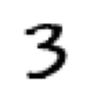

In [14]:
show_image(three_tensors[1]);

对于每个像素位置，我们想要计算该像素强度的所有图像的平均值。为此，我们首先将此列表中的所有图像组合成一个三维张量。描述此类张量的最常见方式是将其称为 rank-3 张量。

可以将二维张量相信成一张纸，所谓合成三维张量就像把多张形状相同的纸（二维张量）一层一层地堆叠起来形成一个长方体。

PyTorch 中的某些作（例如取平均值）需要我们将整数类型转换为浮点类型。由于我们稍后会需要它，因此我们现在还将 stacked tensor 转换为 float。在 PyTorch 中进行强制转换非常简单，只需键入要强制转换的类型的名称，并将其视为一种方法即可。

通常，当图像为浮点数时，像素值预期在 0 和 1 之间，因此我们在这里也要除以 255：

In [15]:
# 将图像张量列表转换为一个统一的、可批处理的张量，并进行归一化
# torch.stack() 是 PyTorch 中的一个函数，用于将一系列张量沿着一个新维度进行拼接（堆叠）
stacked_sevens = torch.stack(seven_tensors).float()/255
stacked_threes = torch.stack(three_tensors).float()/255
# 用于验证数据批次是否按照预期形成了正确的形状
stacked_threes.shape

torch.Size([6131, 28, 28])

根据上面执行结果 (6131, 28, 28)

它的形状是 (6131, 28, 28)。这个形状告诉我们：
* 第一个轴（维度）的长度是 6131。这通常表示我们有 6131 个样本，在这个上下文中是 6131 张图像。
* 第二个轴的长度是 28。这通常表示每张图像的高度是 28 像素。
* 第三个轴的长度是 28。这通常表示每张图像的宽度是 28 像素。

对于 PyTorch 来说，一个形状为 (6131, 28, 28) 的张量仅仅是在内存中存储的一串数字，按照这个特定的多维结构排列。**张量的形状只是数据的组织结构，而每个维度代表什么含义，是由我们根据实际应用场景来解释的**


张量形状的长度

In [16]:
len(stacked_threes.shape)

3

张量的**秩就是张量的维度数量，也就是 `shape` 元组的长度。**

* 对于一个标量（例如 `5`），其 `shape` 是 `()`（空元组），因此秩是 0。
* 对于一个向量（例如 `[1, 2, 3]`），其 `shape` 是 `(3,)`，因此秩是 1。
* 对于一个矩阵（例如 `[[1, 2], [3, 4]]`），其 `shape` 是 `(2, 2)`，因此秩是 2。
* 对于我们例子中的图像张量，其 `shape` 是 `(6131, 28, 28)`，因此秩是 3（它是一个 rank-3 张量或三维张量）。

**理解张量的两个基本属性：**
1.  **形状 (shape):** 描述了张量在每个维度上的大小，是理解数据组织方式的关键。
2.  **秩 (rank):** 描述了张量的维度数量。


**rank 是张量中的轴或维度的数量;shape 是张量每个轴的大小**

---

**注意："维度"（dimension）在不同语境下的不同含义**

1. **物理空间中的“维度” vs. 张量的“秩”（rank）**
* 物理空间的三维性：当我们说“三维空间”时，是指描述一个点的位置需要 三个独立参数（例如 x, y, z 坐标）。这里的“维度”指的是 空间方向的数量，每个方向对应一个轴（axis），且每个轴的长度（元素数量）可能不同。

* 张量的秩（rank）：在 PyTorch 中，`v.ndim` 返回张量的 秩（即轴的个数），而非每个轴的长度。例如：

* 一个三维空间位置向量 `v = [1, 2, 3]` 在 PyTorch 中是 一维张量，因为它的 `ndim=1`，仅有一个轴，该轴的长度为 3（`shape=[3]`）。

* 矩阵（二维张量）的 `ndim=2`，因为它有两个轴（行和列）。


> 关键区分：  
> - 物理中的“三维”对应张量的 某个轴的长度（如 `shape=[3]`）；  
> - 张量的“维度”（`ndim`）实际是 秩（轴的个数）。

2. **术语歧义的根源**

* “维度”一词的多义性：

  * 轴的数量（Rank）：在张量中，`ndim` 表示秩（如矩阵是二维张量）。

  * 轴的长度（Size/Shape）：在物理中，“三维”指每个轴的长度（如 `shape=[3]`）。

* 混淆示例：

  * 若有人说“三维张量”，可能指：

    1. 秩为 3 的张量（如 `shape=[2,3,4]`，三个轴）；
    2. 物理空间中某个轴的长度为 3 的张量（如 `shape=[3]`，秩为 1）。

3. **如何避免混淆？**
建议使用无歧义的术语：
* 秩（Rank）：张量的轴数（`ndim`）。

* 轴（Axis）：张量的某个独立方向（如矩阵的行或列）。

* 长度（Shape）：每个轴上的元素数量（如 `shape=[3,4]` 表示第一轴长 3，第二轴长 4）。


举例说明：
* 物理位置向量 `v = [x, y, z]` 在 PyTorch 中：

* 秩为 1（一维张量）；

* 轴长度为 3（`shape=[3]`）；

* 它的“三维性”体现在轴的长度上，而非张量的秩。


4. **总结：理解张量的核心属性**
* `ndim`（秩）：轴的个数（如向量=1，矩阵=2）。

* `shape`（形状）：每个轴的长度（如 `shape=[3,4]` 表示二维张量，第一轴长 3，第二轴长 4）。

* 物理意义的“维度”：通常对应 `shape` 中的某个值，而非 `ndim`。


> 实际应用：在 PyTorch 中，讨论张量时应明确使用 秩、轴、形状，而非物理中的“维度”概念，以避免误解。

也可以使用 ndim 获取张量的秩：

In [17]:
stacked_threes.ndim

3

对于每个像素位置，这将计算该像素在所有图像上的平均值。结果将是每个像素位置一个值，或单个图像

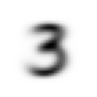

In [18]:
mean3 = stacked_threes.mean(0)
show_image(mean3);

PyTorch张量的 mean 方法表示沿指定维度求均值

* **秩 (Rank)**：指的是张量的**轴的数量**，也就是 `shape` 元组的长度。对于 `stacked_threes`，如果它的形状是 `(num_images, height, width)`，那么它的秩是 **3**。

* **维度 (Dimension) 的索引**：当我们说“维度 0”、“维度 1”、“维度 2” 时，我们是在指张量的**不同轴**。

* **维度的大小 (Length of the axis)**：每个维度都有其大小。在 `stacked_threes` 中：
    * 维度 0 的大小是 `num_images`。
    * 维度 1 的大小是 `height`。
    * 维度 2 的大小是 `width`。

**所以，`stacked_threes` 的秩是 3，表示它有三个轴（维度）。**

你可能会想用“秩”来指代 `num_images`，但更准确的说法是：

* **维度 0 的大小** 表示图像的数量。
* **沿着秩为 0 的轴** 进行 `mean()` 操作，会对所有图像的对应像素取平均。

**为了避免歧义，我们可以这样说：**

在 `stacked_threes` 张量中（假设形状为 `(num_images, height, width)`）：

* **维度 0** 是图像数量的维度，其大小是 `num_images`。
* **维度 1** 是高度的维度，其大小是 `height`。
* **维度 2** 是宽度的维度，其大小是 `width`。

当我们对 `stacked_threes` 使用 `mean(0)` 时，我们是在**沿着图像数量这个维度**进行平均。

**总结：**

* **秩**是轴的数量。
* **维度索引**用于指代特定的轴。
* 每个维度都有其**大小**。

关于mean的参数，对于一个秩为 n 的张量，参数的取值范围是 ​​[-n, n-1]​​，允许正数和负数索引

比如使用 `stacked_threes` 的形状 `(num_images, height, width)` 来解释：

* **正向索引：**
    * 维度 `0` 是第一个维度（图像数量）。
    * 维度 `1` 是第二个维度（高度）。
    * 维度 `2` 是第三个维度（宽度）。

* **负向索引：**
    * 维度 `-1` 是**最后一个**维度（宽度）。
    * 维度 `-2` 是**倒数第二个**维度（高度）。
    * 维度 `-3` 是**倒数第三个**维度（图像数量）。

**所以，负数索引并不是从“不同的方向开始计算”平均值本身，而是提供了一种不同的方式来**指定**你想要进行平均操作的维度。** 计算平均值的过程（对该维度上的所有元素取平均）是相同的，只是你指定维度的**方式**不同。

对 7 做同样的事情

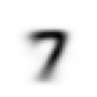

In [19]:
mean7 = stacked_sevens.mean(0)
show_image(mean7);

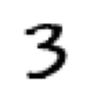

In [20]:
# 从训练集里，取出索引1的手写数字 3 的图片
a_3 = stacked_threes[1]
show_image(a_3);


当需要量化图像与理想目标（如数字 "3"）的差异时，直接对像素差异求和会产生误导：正负差异相互抵消（例如某区域过暗补偿另一区域过亮），导致总差异看似为零。为解决此问题，需采用两种数学方法消除符号干扰。

---

**方法一：L1 范数（Mean Absolute Difference）**
1. **计算原理**
* **数学公式**：  

  $ L1 = \frac{1}{n} \sum_{i=1}^{n} |x_i - y_i| $

  其中 \(x_i\) 是实际像素值，\(y_i\) 是理想像素值，\(n\) 是像素总数。

* **关键操作**：  对每个像素的差异取绝对值后求平均，消除正负抵消效应。

2. **技术特性**

* **对异常值的鲁棒性**：  

  L1 对单个大误差的敏感度较低（绝对值线性增长），适用于存在噪声或离群点的场景。例如，若图像局部存在异常光斑，L1 的误差增幅较小。

* **稀疏性优势**：  

  在优化过程中，L1 倾向于产生稀疏解（部分差异归零），有助于识别关键差异区域。

* **计算效率**：  

  无需平方运算，计算速度较快，适用于实时系统。

3. **应用示例**  
假设理想数字 "3" 的某像素值为 200，实际图像中该像素值为 180，另一像素值为 220：  

* **直接差异**：\( (180-200) + (220-200) = -20 + 20 = 0 \)（错误结论）  

* **L1 差异**：\( |180-200| + |220-200| = 20 + 20 = 40 \)（正确反映总差异）


---

**方法二：L2 范数（Root Mean Squared Error, RMSE）**
1. **计算原理**
* **数学公式**：  

  $ L2 = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (x_i - y_i)^2} $
  
  先对差异平方以消除符号，再求均方根。

2. **技术特性**
* **对大差异的敏感性**：  

  平方运算放大较大误差的影响，使模型更关注显著偏离目标的情况。例如，若某像素差异为 50，其对 L2 的贡献为 2500，远高于 L1 的 50。
* **平滑优化特性**：  

  平方函数处处可导，利于梯度下降等优化算法稳定收敛。
* **物理意义**：  

  RMSE 的单位与原始数据一致（因平方根操作），便于直观解释。

3. **应用示例**  
同一场景下：  
* **L2 差异**：

$ \sqrt{(180-200)^2 + (220-200)^2} = \sqrt{400 + 400} ≈ 28.28 $

  相比 L1 的 40，L2 更强调单个像素的偏离程度。

---

**方法对比与选择建议**

| 维度         | L1 范数                          | L2 范数                          |
|-------------------|--------------------------------------|--------------------------------------|
| 误差分布敏感性   | 对异常值不敏感                       | 对大误差敏感                         |
| 优化特性       | 可能收敛至多个局部最优解             | 单一全局最优解                       |
| 计算复杂度     | 低（无需平方运算）                   | 略高（需平方与开方）                 |
| 典型应用场景   | 图像去噪、特征选择               | 高精度配准、质量评估             |


**选择策略**：
* **优先 L1**：若差异分析需排除噪声干扰（如医学图像中的伪影）或强调关键区域。

* **优先 L2**：若需精确量化整体偏离程度（如卫星图像配准）或依赖梯度优化。


---

**扩展：其他相关度量**
1. **Huber Loss**：  
   结合 L1 和 L2 的优点，对小误差使用平方项，对大误差切换为线性项，平衡鲁棒性与敏感性。
2. **结构相似性（SSIM）**：  
   超越像素级差异，从亮度、对比度、结构三方面评估图像相似性，适用于人类视觉感知优化。

---

通过合理选择 L1 或 L2 范数，可有效解决像素差异抵消问题，并为图像质量评估、目标识别等任务提供量化依据。实际应用中常结合交叉验证确定最优方法。

**鲁棒性（Robustness）的定义**

鲁棒性（Robustness）指系统、模型或算法在面对数据扰动、噪声、异常值或分布变化时，仍能保持稳定性和可靠性的能力。在统计学和机器学习中，对异常值的鲁棒性特指模型或方法对数据中极端值（异常值）的敏感度较低，即使存在少量异常值，也能给出准确且一致的结果。

---

**鲁棒性的核心思想**
1. **抗干扰能力**

   鲁棒性强调在数据存在噪声、缺失值或异常值时，模型不会因这些干扰而崩溃或产生严重偏差。例如，使用中位数（而非均值）作为位置估计量时，对极端值的影响更小。  
   * 示例：若数据集包含少数极高薪资（异常值），用均值计算平均薪资会被拉高，而中位数则能更稳健地反映典型薪资水平。


2. **分布适应性**  
   鲁棒方法不依赖严格的数据分布假设（如正态分布），能够适应非对称、偏态或未知分布的数据。  
   * 示例：鲁棒回归模型（如Huber回归）在存在异常值时，仍能拟合出合理的回归线，而普通线性回归可能被异常值严重干扰。


3. **稳定性与泛化性**

   鲁棒模型在训练数据与测试数据分布不同（分布偏移）时，仍能保持较好的性能。例如，在金融欺诈检测中，即使欺诈模式随时间变化，鲁棒模型仍能有效识别新类型的异常交易。

---

**对异常值的鲁棒性具体表现**
1. **异常值敏感性低**  
   * 传统方法问题：如均值和标准差对异常值敏感，一个极端值可能使结果严重偏离真实情况。  

   * 鲁棒替代方法：  

     * 用中位数代替均值，用MAD（Median Absolute Deviation）代替标准差。  

     * 使用L1范数（MAE）而非L2范数（MSE）作为损失函数，减少大误差的权重。


2. **异常值处理机制**  
   * **检测与剔除**：通过统计方法（如箱线图、Z-score）或机器学习方法（如孤立森林、LOF算法）识别异常值，再决定保留、修正或剔除。  

   * **建模兼容性**：鲁棒模型（如随机森林、支持向量机）在训练时自动降低异常值的影响，而非依赖预处理。


3. **结果可靠性**  
   * 即使数据包含一定比例的异常值，鲁棒方法的输出结果仍接近真实值。例如，在图像识别中，鲁棒模型对输入图像的噪声或遮挡具有更强的容忍度。


---

**鲁棒性的应用场景**
1. **数据分析与统计建模**  
   * **金融领域**：处理市场波动中的极端交易数据。  

   * **医疗领域**：识别罕见疾病数据，避免误诊。


2. **机器学习与深度学习**  
   * **异常检测**：如信用卡欺诈检测、工业设备故障预警。  

   * **模型优化**：通过对抗训练、正则化技术（如Dropout、权重约束）提升模型鲁棒性。


3. **工程与控制系统**
   * **自动驾驶**：在传感器噪声或环境干扰下稳定决策。  

   * **制造业**：在设备数据存在测量误差时，仍能准确预测故障。


---

**增强鲁棒性的方法**
1. **数据预处理**  
   * 清洗噪声数据、填充缺失值、标准化/归一化。  

   * 使用重采样技术（如Bootstrap）评估参数稳定性。


2. **算法选择**  
   * 优先选择非参数方法（如K近邻、决策树）或集成学习（如随机森林）。  

   * 采用鲁棒损失函数（如Huber损失、分位数损失）。


3. **模型设计**  
   * 引入正则化（L1/L2正则化）防止过拟合。  

   * 对抗训练：生成对抗样本并加入训练集，提升模型对扰动的抵抗力。


---

**总结**

鲁棒性是现代数据科学和机器学习的核心要求之一，尤其在现实数据普遍存在噪声和异常值的场景下。通过选择鲁棒方法、优化数据流程和模型设计，可显著提升系统在复杂环境中的可靠性。如需进一步了解具体算法（如MAD计算、LOF异常检测）或应用案例，可参考相关文献或技术文档。

In [21]:
# 使用L1范数
# a_3是训练集里索引1的手写数字 3 的图片
# mean3是沿着图像数量这个维度进行平均后的张量
dist_3_abs = (a_3 - mean3).abs().mean()
# 使用L2范数
dist_3_sqr = ((a_3 - mean3)**2).mean().sqrt()
dist_3_abs,dist_3_sqr

(tensor(0.1114), tensor(0.2021))

In [22]:
dist_7_abs = (a_3 - mean7).abs().mean()
dist_7_sqr = ((a_3 - mean7)**2).mean().sqrt()
dist_7_abs,dist_7_sqr

(tensor(0.1586), tensor(0.3021))

在这两种情况下，我们的 3 和“理想”3 之间的距离都小于到理想 7 的距离。因此，在这种情况下，我们的简单模型将给出正确的预测。

1.  **PyTorch 提供内置的损失函数：** PyTorch 的 `torch.nn.functional` 模块（通常导入为 `F`）包含了许多常用的神经网络函数，包括我们讨论的平均绝对差（L1 范数）和均方根误差（RMSE 或 L2 范数）。

2.  **推荐的导入方式：** PyTorch 团队建议将 `torch.nn.functional` 模块导入为 `F`。fastai 库也遵循这个惯例，因此在 fastai 环境中，你可以直接使用 `F` 来访问这些函数。

3.  **计算 `a_3` 与 `mean7` 之间的距离：** 代码 `F.l1_loss(a_3.float(), mean7), F.mse_loss(a_3, mean7).sqrt()` 展示了如何使用这两个函数来计算一个数字 3 的图像张量 `a_3` 与“理想”数字 7 的图像张量 `mean7` 之间的距离。


In [23]:
# mse_loss 代表均方误差 ，l1_loss 指的是平均绝对值的标准数学术语（在数学中称为 L1 范数 ）
# L1 范数和均方误差 （MSE） 之间的区别在于，后者会比前者更严厉地惩罚较大的错误（并且对小错误更宽容）
F.l1_loss(a_3.float(),mean7), F.mse_loss(a_3,mean7).sqrt()

(tensor(0.1586), tensor(0.3021))

## 激活函数和损失函数

**损失函数（Loss Function）**

**定义与作用**

损失函数是机器学习与深度学习中用于量化模型预测值与真实值之间差异的数学工具。它通过计算模型输出的误差，为参数优化提供方向，是模型训练的核心指标。

* **核心功能**：

  * **评估性能**：衡量模型预测的准确性，损失值越小表示模型越接近真实结果。

  * **指导优化**：作为优化算法（如梯度下降）的目标函数，通过最小化损失调整模型参数。

  * **正则化**：某些损失函数（如L1/L2）可加入正则项，防止过拟合。


**常见类型**

1. **回归任务**：
   * **L1损失（MAE）**：计算绝对误差，对异常值鲁棒，适用于数据噪声较大的场景。

   * **L2损失（MSE）**：计算平方误差，对离群点敏感，常用于精确回归。

   * **Huber损失**：结合L1和L2特性，对小误差平滑处理，对大误差线性处理，平衡鲁棒性与敏感性。


2. **分类任务**：
   * 交叉熵损失：衡量概率分布差异，多用于分类模型（如逻辑回归、神经网络）。

   * Hinge损失：支持向量机（SVM）的核心，通过最大化分类边界提升稀疏性。

   * 指数损失：AdaBoost算法的关键，对错误分类样本施加指数级惩罚，加速模型迭代。


**应用场景**
* **工业优化**：例如工厂通过损失函数计算最佳通风条件，以最小化额外成本。

* **模型训练**：如PyTorch中的`F.l1_loss`和`F.mse_loss`直接用于参数调优。


---

**激活函数（Activation Function）**

**定义与作用**

激活函数是神经网络中引入非线性的核心组件，决定神经元是否被激活及输出强度，使模型能够拟合复杂数据模式。

* **核心功能**：

  * **引入非线性**：打破线性限制，使网络能够学习复杂函数（如图像识别中的边缘检测）。

  * **梯度控制**：防止梯度消失或爆炸，例如ReLU在正区间保持梯度稳定。

  * **输出规范化**：将输出限制到特定范围（如Sigmoid映射到0-1，适合概率输出）。


**常见类型**
1. **Sigmoid**：输出0-1区间，适用于二分类的概率输出，但易导致梯度消失。
2. **Tanh**：输出-1到1区间，零中心化特性有利于优化过程，但仍存在梯度问题。
3. **ReLU**：正区间梯度为1，计算高效，广泛用于隐藏层，但可能导致“死亡神经元”。
4. **LeakyReLU/ELU**：改进ReLU的负区间处理，缓解神经元死亡问题。
5. **Softmax**：多分类任务中归一化输出为概率分布。

**应用场景**
* **隐藏层**：通常选择ReLU或其变体以提升训练效率。

* **输出层**：根据任务选择激活函数（如二分类用Sigmoid，多分类用Softmax）。


---

**区别与联系**

| 维度       | 损失函数                     | 激活函数                     |
|----------------|----------------------------------|----------------------------------|
| 功能定位   | 全局模型性能评估与优化目标       | 局部神经元非线性转换              |
| 数学作用   | 计算预测值与真实值的误差         | 决定神经元输出值                  |
| 典型示例   | 交叉熵、MSE                     | ReLU、Sigmoid                   |
| 优化关联   | 直接指导参数更新方向             | 影响反向传播梯度计算              |
| 任务适配性 | 需匹配任务类型（分类/回归）      | 需匹配网络层需求（隐藏层/输出层） |

**协同作用**

* 在神经网络中，激活函数处理单层非线性，而损失函数综合各层误差指导整体优化。例如，交叉熵损失需搭配Softmax激活函数实现多分类概率输出。


---

**总结**

损失函数和激活函数是深度学习的核心组件。前者作为“导航仪”评估和优化模型，后者作为“引擎”赋予网络非线性能力。合理选择两者（如回归任务用MSE+ReLU，分类任务用交叉熵+Softmax）可显著提升模型性能。更多细节可参考[PyTorch文档](https://pytorch.org/docs/stable/nn.html#loss-functions)或相关论文。

### NumPy 数组 和 PyTorch 张量


**1. NumPy 与 PyTorch 的共性**

两者均提供多维数组操作的 API，支持高效的数学运算（如矩阵乘法、广播机制等）。例如，以下代码在两种库中行为相似：
```python
# NumPy
import numpy as np
arr = np.array([[1, 2], [3, 4]])
result = arr * 2  # 输出 [[2,4], [6,8]]

# PyTorch
import torch
tensor = torch.tensor([[1, 2], [3, 4]])
result = tensor * 2  # 输出 tensor([[2,4], [6,8]])
```

---

**2. 为何深度学习选择 PyTorch 张量？**

尽管 API 相似，PyTorch 张量在以下关键特性上超越 NumPy 数组：

**（1）GPU 加速支持**

* **PyTorch张量**可通过 `.to("cuda")` 移动到 GPU 上计算，利用 CUDA 并行架构加速大规模矩阵运算。例如：

  ```python
  if torch.cuda.is_available():
      tensor_gpu = tensor.cuda()  # 将张量移至 GPU
  ```
* NumPy：仅支持 CPU 计算，无法直接利用 GPU 的并行能力。


**（2）自动微分（Autograd）**

* **PyTorch**：通过 `requires_grad=True` 跟踪张量操作，使用 `.backward()` 自动计算梯度。例如：

  ```python
  x = torch.tensor(3.0, requires_grad=True)
  y = x**2 + 2*x
  y.backward()  # 自动计算 dy/dx = 8.0
  ```
* **NumPy**：无内置梯度计算功能，需手动实现反向传播。


**（3）动态计算图**

* **PyTorch**：支持动态图机制，允许在运行时根据条件分支或循环修改计算流程。例如：

  ```python
  def dynamic_model(x):
      if x.sum() > 0:
          return x * 2
      else:
          return x - 1
  ```
* **NumPy**：仅提供静态数组操作，无法构建动态计算图。


---

**3. 为何 NumPy 仍不可替代？**

**（1）通用科学计算**

NumPy 是 Python 科学计算生态的基石，与 Pandas、Matplotlib 等库深度集成，适合数据分析、信号处理等非深度学习场景。

**（2）轻量级与稳定性**

对于小规模数据或无需 GPU/梯度计算的场景，NumPy 的 CPU 实现更轻量且稳定。

**（3）协同工作**

两者可通过零拷贝转换无缝协作：
```python
# NumPy 转 Tensor（共享内存）
np_array = np.ones(5)
torch_tensor = torch.from_numpy(np_array)

# Tensor 转 NumPy（共享内存）
torch_tensor = torch.ones(5)
np_array = torch_tensor.numpy()
```

---

**4. 总结与选择建议**

| 维度       | NumPy 数组                  | PyTorch 张量                  |
|----------------|--------------------------------|-----------------------------------|
| 核心用途   | 通用科学计算、数据分析         | 深度学习模型开发与训练            |
| 硬件加速   | 仅 CPU                         | 支持 GPU/CUDA 加速               |
| 自动求导   | 不支持                         | 通过 `autograd` 支持              |
| 动态图     | 不支持                         | 支持运行时动态修改计算流程        |
| 内存管理   | 不可变数组，可能产生内存拷贝   | 视图机制优化内存共享              |

选择策略：
* **深度学习任务**：优先使用 PyTorch 张量，利用其 GPU 加速、自动微分和动态图特性。

* **传统科学计算**：使用 NumPy 数组，结合 Pandas、SciPy 等库完成数据处理。


---

**5. 扩展说明**

• **Fastai 的增强功能**：Fastai 库对 NumPy 和 PyTorch 进行了扩展，使两者的 API 更加接近。例如，用户可通过 `from fastai.vision.all import *` 引入兼容性支持。

• **性能优化**：PyTorch 张量在底层融合操作（如矩阵乘法 + ReLU 激活）以减少 GPU 内核调用次数，而 NumPy 无此类优化。

In [24]:
data = [[1,2,3],[4,5,6]]
# numpy 创建数组
arr = array (data)
# pytorch 创建张量
tns = tensor(data)

In [25]:
arr

array([[1, 2, 3],
       [4, 5, 6]])

In [26]:
tns

tensor([[1, 2, 3],
        [4, 5, 6]])

In [27]:
# 访问 tns 张量的第二个行（索引从 0 开始）。
# tns 是一个 2x3 的张量：
tns[1]



tensor([4, 5, 6])

In [28]:
# 对比NumPy 数组的语法和结果
arr[1]

array([4, 5, 6])

In [29]:
# 这里的 : 表示选择所有行, 后面跟着 1 表示选择索引为 1 的列（即每行的第二个元素）。
tns[:,1]

tensor([2, 5])

In [30]:
# 对比NumPy 数组的语法和结果
arr[:,1]

array([2, 5])

In [31]:
# 1 表示选择索引为 1 的行，即 [4, 5, 6], 后面跟着 1:3 表示在该行中选择从索引 1 开始到索引 3 之前的元素（切片操作）。
tns[1,1:3]

tensor([5, 6])

In [32]:
# 对比NumPy 数组的语法和结果
arr[1,1:3]

array([5, 6])

In [33]:
# 这是一个**广播（broadcasting）**操作。标量 1 会被广播到 tns 张量的每一个元素上，然后进行加法运算。
# tns 的每个元素都会加 1。
tns+1

tensor([[2, 3, 4],
        [5, 6, 7]])

In [34]:
# 对比NumPy 数组的语法和结果
arr+1

array([[2, 3, 4],
       [5, 6, 7]])

In [35]:
# 查看张量类型
tns.type()

'torch.LongTensor'

In [36]:
# NumPy 数组通过python的type返回 arr 对象本身的 Python 类型
type(arr)

numpy.ndarray

In [37]:
# NumPy 数组 通过访问数组属性dtype获取它的数据类型
arr.dtype

dtype('int64')

In [38]:
type(tns)

torch.Tensor

In [39]:
tns.dtype

torch.int64

详细解释一下 `tns.type()`, `tns.dtype`, `type(tns)`, `arr.dtype`, 和 `type(arr)` 之间的区别以及它们的使用场景。

**假设我们有以下 PyTorch 张量 `tns` 和 NumPy 数组 `arr`:**

```python
import torch
import numpy as np

tns = torch.tensor([[1, 2, 3], [4, 5, 6]])
arr = np.array([[1, 2, 3], [4, 5, 6]])
```

**1. `tns.type()` (PyTorch 张量)**

  * **返回值:** 返回一个字符串，表示张量的具体类型，包括其数据类型和所在的设备（例如 CPU 或 CUDA）。
  * **示例:** 对于上面的 `tns`，`tns.type()` 通常会返回 `'torch.LongTensor'`。如果 `tns` 是浮点数张量在 CUDA 上，可能会返回 `'torch.cuda.FloatTensor'`。
  * **用途:** 主要用于获取张量的完整类型信息，包括数据类型和设备信息。在需要打印或记录张量的完整类型时很有用。

**2. `tns.dtype()` (PyTorch 张量)**

  * **返回值:** 返回一个 `torch.dtype` 对象，表示张量中元素的数据类型。
  * **示例:** 对于上面的 `tns`，`tns.dtype` 会返回 `torch.int64` (因为默认情况下整数张量是 64 位整数)。如果创建时指定了 `dtype=torch.int32`，则会返回 `torch.int32`。
  * **用途:** 主要用于获取和设置张量中元素的数据类型。在需要进行类型转换或检查张量的数据类型时非常有用。

**为什么 `tns.type()` 返回 `torch.LongTensor` 而 `tns.dtype()` 返回 `torch.int64`？**

  * `torch.LongTensor` 是 PyTorch 中表示 64 位整数张量的**具体类型名称**。它包含了数据类型 (`torch.int64`) 和张量在 CPU 上的存储方式。
  * `torch.int64` 则是张量中**每个元素的数据类型**，即 64 位整数。

你可以把 `tns.type()` 看作是对 `tns` 更完整的描述，而 `tns.dtype()` 更专注于元素级别的数据类型。

**3. `type(tns)` (PyTorch 张量)**

  * **返回值:** 返回 `tns` 对象本身的 Python 类型。
  * **示例:** 对于任何 PyTorch 张量 `tns`，`type(tns)` 将始终返回 `<class 'torch.Tensor'>`。
  * **用途:** 用于判断 `tns` 是否是一个 PyTorch 张量对象。

**4. `arr.dtype` (NumPy 数组)**

  * **返回值:** 返回一个 `numpy.dtype` 对象，表示数组中元素的数据类型。
  * **示例:** 对于上面的 `arr`，`arr.dtype` 会返回 `int64` (在某些系统上可能是 `int32`)。如果创建时指定了 `dtype=np.float32`，则会返回 `float32`。
  * **用途:** 与 PyTorch 的 `tns.dtype()` 类似，用于获取和设置 NumPy 数组中元素的数据类型。

**5. `type(arr)` (NumPy 数组)**

  * **返回值:** 返回 `arr` 对象本身的 Python 类型。
  * **示例:** 对于任何 NumPy 数组 `arr`，`type(arr)` 将始终返回 `<class 'numpy.ndarray'>`。
  * **用途:** 用于判断 `arr` 是否是一个 NumPy 数组对象。

**总结和使用场景:**

| 操作         | 适用对象      | 返回值类型         | 示例返回值              | 主要用途                                                                 |
|--------------|---------------|------------------|-----------------------|------------------------------------------------------------------------|
| `tns.type()`   | PyTorch 张量  | 字符串            | `'torch.LongTensor'`  | 获取张量的完整类型信息 (数据类型 + 设备)                               |
| `tns.dtype`  | PyTorch 张量  | `torch.dtype` 对象 | `torch.int64`         | 获取/设置张量元素的数据类型，进行类型转换或检查                             |
| `type(tns)`  | PyTorch 张量  | `<class 'torch.Tensor'>` | `<class 'torch.Tensor'>` | 判断对象是否是 PyTorch 张量                                              |
| `arr.dtype`   | NumPy 数组    | `numpy.dtype` 对象 | `int64`               | 获取/设置数组元素的数据类型，进行类型转换或检查                             |
| `type(arr)`   | NumPy 数组    | `<class 'numpy.ndarray'>` | `<class 'numpy.ndarray'>` | 判断对象是否是 NumPy 数组                                                |

**具体使用时机:**

  * 当你需要知道张量是在 CPU 还是 GPU 上，以及它的基本数据类型名称时，使用 `tns.type()`.
  * 当你需要确保张量具有特定的数值数据类型（例如进行浮点运算时需要 `torch.float32`），或者需要将张量转换为不同的数据类型时，使用 `tns.dtype` 或 `arr.dtype`。
  * 当你需要判断一个变量是否是 PyTorch 张量或 NumPy 数组时，使用 `type(tns)` 或 `type(arr)`.

记住，PyTorch 和 NumPy 是独立的库，它们在表示和处理多维数组（张量）时有一些相似的概念，但具体的 API 和类型系统有所不同。理解这些差异对于在深度学习和数值计算中正确地使用这两个库至关重要。

In [40]:
# 如果原始张量 tns 的数据类型是整数类型（例如 torch.int64, torch.int32），
# 那么结果张量的数据类型通常会自动转换为浮点数类型
#（通常是 torch.float32，但也可能是 torch.float64，取决于 PyTorch 的默认设置或张量的初始类型），以保留乘法结果的小数部分。
tns*1.5

tensor([[1.5000, 3.0000, 4.5000],
        [6.0000, 7.5000, 9.0000]])

In [41]:
# NumPy数组的也会根据需要自动转换类型
# 但是NumPy 在打印数组时默认会根据数组的数据类型和数值进行格式化，并且可能会省略小数点后的零
arr*1.5

array([[1.5, 3. , 4.5],
       [6. , 7.5, 9. ]])

接下来需要定义一个指标来判断之前的基准模型是否好用

原文关于指标这段内容核心在于解释**模型评估指标**的重要性，特别是**准确率**在分类任务中的地位，以及使用**验证集**来避免**过拟合**的必要性。

* **模型评估指标的核心概念：** 原文首先指出**指标（metric）**是一个基于模型预测和真实标签计算出来的数值，用于衡量模型的好坏。它提到了回归任务中常用的 **均方误差（MSE）**和 **平均绝对误差（MAE）** 作为例子，但强调这些指标对于大多数人来说不够直观。因此，对于**分类模型**，通常使用 **准确率（Accuracy）**。正如你所解释的，准确率是模型预测正确的样本比例，更易于理解，尤其是在类别分布相对均衡的情况下。

* **验证集的作用与必要性：** 原文接着强调了在 **验证集（validation set）** 上计算评估指标的重要性。这是为了防止模型**过拟合**，即模型只在训练数据上表现良好，而在新数据上表现不佳。验证集作为一个独立的评估数据，可以帮助我们了解模型的泛化能力。你详细阐述了验证集的核心功能（防止过拟合、模型调优与选择）以及常见的使用实践（数据划分方法、交叉验证），这些都进一步强调了验证集在模型开发流程中的关键作用。


* **为何选择准确率**
  * ​直观性​​：准确率易于理解，适合向非技术背景的受众解释模型效果。
  * 低计算成本​​：对于简单模型（如像素相似性模型），准确率计算高效且无需复杂调参

* **为何即使模型简单仍需验证集**
  * 遵循标准流程​​：为后续复杂模型（如神经网络）建立评估规范，确保实践一致性
  * ​早期问题检测​​：验证集可提前暴露数据划分或预处理中的潜在问题（如数据泄露）。

**总结与扩展：**

虽然原文侧重于准确率和验证集，但是在实际应用中，选择合适的评估指标需要考虑数据的**类别平衡情况**和具体的**业务需求**。例如，在类别不平衡时，**F1 分数、精确率、召回率、ROC 曲线和 AUC 值** 等指标能提供更全面的评估。同样，验证集的划分方式也需要根据数据的特性（如时间序列数据）进行调整。

模型评估需要选择合适的指标来衡量性能，而准确率因其直观性常用于分类任务。为了确保模型能够泛化到新数据，避免过拟合，评估过程必须在独立的验证集上进行。即使对于简单的模型，遵循这样的评估流程也是最佳实践，为后续更复杂的模型开发奠定基础，并有助于及早发现潜在问题。

首先从valid目录为 3 和 7 创建张量。这些是我们将用于计算衡量首次尝试模型质量的指标的张量，该指标测量与理想图像的距离：

In [42]:
# 创建验证集目录下数字3的rank-3 张量
valid_3_tens = torch.stack([tensor(Image.open(o))
                            for o in (path/'valid'/'3').ls()])
# 将张量的数据类型转换为浮点数，并做归一化操作，将像素值从 0-255 的范围缩放到 0-1 的范围。归一化有助于模型的训练过程更加稳定和快速
valid_3_tens = valid_3_tens.float()/255
# 创建验证集目录下数字7的rank-3 张量
valid_7_tens = torch.stack([tensor(Image.open(o))
                            for o in (path/'valid'/'7').ls()])
valid_7_tens = valid_7_tens.float()/255
# 查看valid_3_tens 和 valid_7_tens 这两个张量的形状
valid_3_tens.shape,valid_7_tens.shape

(torch.Size([1010, 28, 28]), torch.Size([1028, 28, 28]))

我们看到结果输出两个张量，一个表示 1010 张大小为 28×28 的图像3的验证集，另一个表示 1028 张大小为 28×28 的图像7的验证集。

定义一个mnist_distance 函数，通过计算两张图像对应像素之间绝对差值的平均值，定义了一个简单的图像距离度量。距离越小，表示两张图像在像素层面上越相似。下一步的目标是使用这个距离函数，将任意手写数字图像与数字 3 的平均图像和数字 7 的平均图像进行比较，并将其归类为距离更近的那个数字

In [43]:
# 参数a: 待测图像张量（如形状为[batch_size, 28, 28]的MNIST图像）
# 参数b: 训练集所有数字 3 图像的平均像素数据
def mnist_distance(a,b):
  return (a-b).abs().mean((-1,-2))

mnist_distance(a_3, mean3)

tensor(0.1114)

mnist_distance 函数的作用是计算两个图像张量 a 和 b 之间的平均绝对误差 (MAE)。这个函数原本是设计用来比较两个单个图像的。

现在引入验证集 valid_3_tens批量调用。valid_3_tens 是一个形状为 [1010, 28, 28] 的张量。这意味着它包含了 1010 张独立的数字 "3" 的图像，每一张图像的形状都是 [28, 28]

In [44]:
valid_3_dist = mnist_distance(valid_3_tens, mean3)
valid_3_dist, valid_3_dist.shape

(tensor([0.1126, 0.1187, 0.1242,  ..., 0.1195, 0.1517, 0.1360]),
 torch.Size([1010]))

将包含 1010 张图像的 valid_3_tens (形状 [1010, 28, 28]) 和代表单个理想数字 "3" 的 mean3 (形状 [28, 28]) 作为参数传递给了原本用于比较两个单张图像的 mnist_distance 函数，PyTorch 没有报错形状不匹配，而是返回了一个形状为 [1010] 的张量 valid_3_dist。这个张量的每一个元素都代表了 valid_3_tens 中对应位置的那张数字 "3" 的图像与 mean3 之间的距离。这种神奇现象的原因：**PyTorch 的广播机制**

**广播的概念:** 当 PyTorch 尝试对两个形状不同的张量进行逐元素操作（例如这里的减法 `(a - b)`），它会尝试自动“扩展”形状较小的张量，使其与形状较大的张量兼容，而无需实际复制数据。

**广播过程详解**
1. **维度对齐​**​：PyTorch将模板mean3（2D）的维度从[28,28]扩展为[1,28,28]（自动补充批次维度）
2. **维度扩展**：进一步将mean3沿批次维度复制1010次，变为[1010,28,28]（无实际数据复制，仅为逻辑视图）
3. **逐元素操作**：执行(valid_3_tens - mean3)，结果为形状[1010,28,28]的张量
4. **均值计算**：.mean((-1,-2))对每张图像的28x28像素取均值，最终得到形状[1010]的距离向量

**广播机制的优势​**
* **避免显式循环**：传统方法需循环处理1010次，而广播一次性完成计算，效率提升数十倍
* **内存优化**：广播通过逻辑扩展而非物理复制数据，节省内存（例如模板数据仅存储一次）
* **简洁性**：广播机制极大地简化了代码。我们不需要显式地编写循环来遍历 valid_3_tens 中的每一张图像并计算其与 mean3 的距离

广播使两个参数张量具有相同的秩后，PyTorch 将其常规逻辑应用于相同秩的两个张量：它对两个张量的每个对应元素执行运算，并返回张量结果。例如：










In [45]:
tensor([1,2,3]) + tensor(1)

tensor([2, 3, 4])

In [46]:
(valid_3_tens-mean3).shape

torch.Size([1010, 28, 28])

继续深入解释了 `mnist_distance` 函数中的 `.abs()` 和 `.mean((-1,-2))` 操作在处理批量图像数据时的行为

**1. 解释 `.abs()` 的行为:**

原文指出，当 `.abs()` 应用于一个张量时，它会对张量中的**每一个单独的元素**执行取绝对值操作，并返回一个包含结果的**相同形状的张量**。

  * 在我们的例子中，当 `(a - b)` 的结果（形状为 `[1010, 28, 28]` 的差值张量）应用 `.abs()` 后，我们仍然得到一个形状为 `[1010, 28, 28]` 的张量。这个张量包含了 1010 个 28x28 的矩阵，每个矩阵的元素都是对应像素差值的绝对值。

**2. 解释 `.mean((-1,-2))` 的行为:**

原文详细解释了 `mean((-1,-2))` 中 `(-1,-2)` 的含义：

  * 在 Python 中，负索引用于从序列的末尾开始计数。`-1` 指的是最后一个元素（或轴），`-2` 指的是倒数第二个元素（或轴）。
  * 对于形状为 `[1010, 28, 28]` 的张量，轴的索引分别是：
      * `0`: 代表图像的索引（1010 张图像）。
      * `1`: 代表图像的垂直维度（高度，28 像素）。
      * `2`: 代表图像的水平维度（宽度，28 像素）。
  * 因此，`mean((-1,-2))` 告诉 PyTorch 对张量的**最后两个轴**（即高度和宽度维度）的值计算平均值。
  * 对于 `[1010, 28, 28]` 的张量，对后两个维度取平均后，形状会变为 `[1010]`。这是因为对于每一张图像（第一个轴），我们将其所有像素的绝对差值取了一个平均值，得到了一个单一的数值（距离）。
  * 原文总结说，对于每一张图像，我们计算了该图像中所有像素强度值的平均差异。

**关于mean((-1,-2))的计算方式**

`mean((-1, -2))` 的平均值计算是针对张量的**最后两个维度**的所有元素进行的

用一个具体的例子来说明。假设有一个形状为 `[1010, 28, 28]` 的张量，对其执行 `mean((-1, -2))`。

对于这个张量中的**每一张图像**（沿着第一个维度，大小为 1010），它本身是一个形状为 `[28, 28]` 的二维数组（可以想象成一个像素矩阵）。

`mean((-1, -2))` 的计算过程是这样的：

1.  **选取一张图像 (28x28 的矩阵):**

    ```
    [[p1_1, p1_2, ..., p1_28],
     [p2_1, p2_2, ..., p2_28],
     ...
     [p28_1, p28_2, ..., p28_28]]
    ```

    这里的 `p_ij` 代表位于第 `i` 行（高度）第 `j` 列（宽度）的像素值（或者在这个上下文中，是与理想数字对应像素的绝对差值）。

2.  **计算所有元素的平均值:** `mean((-1, -2))` 会将这个 28x28 矩阵中的**所有** 28 \* 28 = 784 个元素加起来，然后除以 784。

    ```
    average = (p1_1 + p1_2 + ... + p1_28 +
               p2_1 + p2_2 + ... + p2_28 +
               ... +
               p28_1 + p28_2 + ... + p28_28) / (28 * 28)
    ```

3.  **对所有图像重复这个过程:** 这个平均值计算会独立地对 `[1010, 28, 28]` 张量中的每一张图像（沿着第一个维度）执行。

**为什么用 mean((-1, -2))，不用 mean((1, 2))**

这涉及到张量维度的索引和我们想要计算平均值的目标。让我们再次回顾 `valid_3_tens` 的形状：`[1010, 28, 28]`。

* **`mean((-1, -2))`:**
    * `-1` 指的是**最后一个维度**，即**宽度** (大小为 28)。
    * `-2` 指的是**倒数第二个维度**，即**高度** (大小为 28)。
    * 因此，`mean((-1, -2))` 会对每个图像（沿着第一个维度）的所有像素值（高度和宽度维度）计算平均值。这正是我们想要的，即得到每个图像与 `mean3` 的**平均像素差异**。

* **`mean((1, 2))`:**
    * `1` 指的是**第二个维度**，即**高度** (大小为 28)。
    * `2` 指的是**第三个维度**，即**宽度** (大小为 28)。
    * 所以，`mean((1, 2))` 的作用与 `mean((-1, -2))` 在这个特定的形状下是**相同的**。它们都会对每个图像的像素值计算平均值。

**结论：** 在这个形状为 `[1010, 28, 28]` 的张量中，`mean((-1, -2))` 和 `mean((1, 2))` 会得到相同的计算结果和形状变化（最终形状为 `[1010]`)。

**那么，为什么代码中选择了 `mean((-1, -2))` 呢？**

这通常是出于以下几个考虑：

* **代码的鲁棒性 (Robustness):** 使用负索引通常更具有鲁棒性，尤其是在处理形状不确定的张量时。如果张量的维度发生变化（例如，如果图像是彩色的，形状变为 `[1010, 28, 28, 3]`），`(-1, -2)` 仍然会指向**最后两个空间维度**（高度和宽度），而 `(1, 2)` 的索引就需要根据新的形状进行调整。在处理图像数据时，我们通常希望对空间维度进行操作，而使用负索引可以更好地适应这种需求。
* **约定俗成 (Convention):** 在处理图像或类似的多维数据时，对最后几个维度（通常是空间或特征维度）进行聚合操作是一种常见的模式，使用负索引可以更简洁地表达这种意图。

**方法里面的数字能调换位置吗？例如 `mean((-2, -1))`？**

`mean((-2, -1))` 和 `mean((-1, -2))` 在这个特定的形状 `[1010, 28, 28]` 下会产生**相同的结果**，但中间的计算过程可能略有不同。

* **`mean((-1, -2))`:** 先在宽度维度上取平均，然后再在高度维度上取平均（或者反过来，由于平均操作的结合律，最终结果相同）。
* **`mean((-2, -1))`:** 先在高度维度上取平均，然后再在宽度维度上取平均（同样，最终结果与上面的相同）。

**更一般地，当 `mean()` 的参数是一个包含多个维度的元组时，它会沿着这些指定的维度依次计算平均值。最终被“消除”的维度就是元组中指定的那些维度。**

**考虑一个更复杂的例子：形状为 `[batch_size, height, width, channels]` 的彩色图像张量。**

* 如果我们想对每个图像的所有像素的 RGB 值取平均，得到每个图像的平均颜色向量，我们会使用 `mean((1, 2))` 或 `mean((-3, -2))`。结果形状将是 `[batch_size, channels]`。
* 如果我们想对每个像素的 RGB 通道取平均，得到灰度图像，我们会使用 `mean(3)` 或 `mean(-1)`。结果形状将是 `[batch_size, height, width]`。
* 如果我们想对每个图像的所有像素的所有颜色通道取平均，得到每个图像的单个平均颜色值，我们会使用 `mean((1, 2, 3))` 或 `mean((-3, -2, -1))`。结果形状将是 `[batch_size]`。

**总结：**

* 对于形状为 `[1010, 28, 28]` 的张量，`mean((-1, -2))` 和 `mean((1, 2))` 在最终结果上是等价的。使用负索引通常更鲁棒。
* `mean()` 方法中元组内数字的顺序在最终的标量平均值结果上通常不重要（由于平均操作的结合律），但它会影响中间计算的形状变化。然而，当我们需要保留某些维度时，指定正确的维度顺序和索引就至关重要。

在我们的图像距离计算场景中，我们最终的目标是将每个 `[28, 28]` 的图像差异矩阵聚合为一个标量距离值，因此对高度和宽度维度取平均的顺序并不影响最终的距离值。

利用 mnist_distance 函数定义了一个判断图像是否为数字 "3" 的函数 is_3

In [47]:
def is_3(x): return mnist_distance(x,mean3) < mnist_distance(x,mean7)

测试它

In [48]:
is_3(a_3), is_3(a_3).float()

(tensor(True), tensor(1.))

当我们将布尔响应转换为浮点数时，True 为 1.0，False 为 0.0。 多亏了广播，我们还可以在完整的 3 验证集上测试它

In [49]:
is_3(valid_3_tens)

tensor([True, True, True,  ..., True, True, True])

现在，我们可以通过取该函数对所有 3 的平均值及其对所有 7 的逆函数来计算每个 3 和 7 的准确率：

In [50]:
# valid_3_tens: 形状为[N,28,28]的3的验证集

# is_3(valid_3_tens): is_3(x) 函数接收一个图像张量 x，并返回一个布尔张量，其形状与 x 的第一个维度相同。
# 对于 valid_3_tens（包含所有数字 "3" 的验证集图像，形状为 [1010, 28, 28])，is_3(valid_3_tens) 会返回一个形状为 [1010] 的布尔张量。
# 这个张量的每个元素都是 True 或 False，表示模型是否认为对应的图像是数字 "3"。理想情况下，对于所有的数字 "3" 的图像，is_3 应该返回 True

# .float(): 将布尔张量转换为浮点数张量。在 PyTorch 中，True 会被转换为 1.0，False 会被转换为 0.0。
# 现在我们得到一个包含 1.0 和 0.0 的形状为 [1010] 的张量。

# .mean(): 计算这个浮点数张量的所有元素的平均值。
# 这意味着将所有 1.0 (模型正确预测为 "3") 和 0.0 (模型错误预测为 "3") 加起来，然后除以总数 (1010)。
# 结果就是模型在数字 "3" 的验证集上的准确率。例如，如果结果是 0.92，则表示模型正确地将 92% 的数字 "3" 识别为 "3"。
accuracy_3s = is_3(valid_3_tens).float() .mean()

# valid_7_tens: 形状为[M,28,28]的7的验证集

# is_3(valid_7_tens): 类似于处理 valid_3_tens，这会对包含所有数字 "7" 的验证集图像（形状为 [1010, 28, 28]，假设 "7" 的验证集大小也为 1010）
# 应用 is_3 函数，得到一个形状为 [1010] 的布尔张量，表示模型是否认为对应的图像是数字 "3"。理想情况下，对于所有的数字 "7" 的图像，is_3 应该返回 False。

# .float(): 将布尔张量转换为浮点数张量 (1.0 代表 True，0.0 代表 False)。

# (1 - ...): 对浮点数张量的每个元素执行 1 - x 的操作。
# 如果模型正确地将一个 "7" 识别为不是 "3" (即 is_3 返回 False，转换为 0.0)，那么 1 - 0.0 的结果就是 1.0。
# 如果模型错误地将一个 "7" 识别为 "3" (即 is_3 返回 True，转换为 1.0)，那么 1 - 1.0 的结果就是 0.0。
# 因此，这个操作创建了一个新的浮点数张量，其中 1.0 表示模型正确地识别为 "非3" (也就是 "7"），0.0 表示模型错误地识别为 "3"。

# .mean(): 计算这个新的浮点数张量的平均值，得到模型在数字 "7" 的验证集上的准确率。
# 例如，如果结果是 0.91，则表示模型正确地将 91% 的数字 "7" 识别为 "非3" (也就是 "7"）。
accuracy_7s = (1 - is_3(valid_7_tens).float()).mean()

# accuracy_3s: 模型在数字 "3" 的验证集上的准确率。
# accuracy_7s: 模型在数字 "7" 的验证集上的准确率。
# (accuracy_3s + accuracy_7s) / 2: 模型在这两个类别上的平均准确率。
accuracy_3s,accuracy_7s,(accuracy_3s+accuracy_7s)/2

(tensor(0.9168), tensor(0.9854), tensor(0.9511))

从结果来看使用简单的基于像素距离（平均绝对误差）的方法，我们已经能够在区分数字 "3" 和 "7" 的验证集上取得了超过 90% 的准确率。

这段代码通过我们定义的距离函数和广播机制，便捷地计算了模型在区分数字 "3" 和 "7" 上的准确率，并初步评估了结果。但是当前的系统只能区分两个数字。为了提高性能并能够区分更多数字，作者认为需要引入一个能够进行真正的学习的系统。这意味着模型应该能够通过学习数据自动调整自身参数以提高性能。接下来，将要讨论**训练过程（training process）**和一种常用的优化算法：**随机梯度下降（Stochastic Gradient Descent, SGD）**

## 随机梯度下降 （SGD）

```
Suppose we arrange for some automatic means of testing the effectiveness of any current weight assignment in terms of actual performance and provide a mechanism for altering the weight assignment so as to maximize the performance. We need not go into the details of such a procedure to see that it could be made entirely automatic and to see that a machine so programmed would "learn" from its experience.
```

这段Arthur Samuel 对机器学习的描述是机器学习的基石。它强调了以下关键点：

  * **权重分配 (weight assignment):** 模型内部存在一些可以调整的参数，这些参数被称为权重。
  * **评估有效性 (testing the effectiveness):** 需要一种自动化的方法来衡量当前权重分配下模型的实际表现（例如，通过准确率、损失函数等）。
  * **调整权重 (altering the weight assignment):** 需要一个自动化的机制来根据模型的表现调整这些权重。目标是改进模型的性能，即“最大化性能”。
  * **自动化学习 ("learn" from its experience):** 通过不断地测试和调整权重，机器能够从数据中“学习”，逐渐提高其解决问题的能力。

**像素相似度方法的局限性:**

我们之前使用的像素相似度方法（比较图像与理想数字的平均图像）并没有真正实现 Samuel 描述的学习过程：

  * **没有权重分配 (no weight assignment):** 该方法没有可以调整的参数（权重）。“理想图像”是通过简单平均计算得到的，是固定的。
  * **无法基于性能改进 (no way of improving based on testing the effectiveness of a weight assignment):** 我们无法通过测试模型的准确率来修改“理想图像”本身，使其变得更好。

因此，像素相似度方法本质上是一个固定的算法，无法通过学习数据来提升性能。

**基于权重的表示：一个更强大的思路:**

为了实现真正的学习，我们需要一种基于权重的方法。作者提出了一个关键的想法：

  * **为每个像素分配权重 (a set of weights for each one):** 不再是比较整体相似性，而是关注每个像素对于识别特定数字的重要性。
  * **高权重赋予关键像素 (highest weights are associated with those pixels most likely to be black for a particular category):** 例如，对于数字 "7"，右下角的像素通常是白色（不激活），因此应该赋予较低的权重。而对于数字 "8"，这些像素很可能是黑色（激活），因此应该赋予较高的权重。



In [5]:
def pr_eight(x, w):
    return (x * w).sum()

* **`x` (image as a vector):** 输入图像 `x` 被表示成一个向量，即将图像的所有行堆叠成一条长线。如果原始图像是 28x28 的，那么 `x` 就是一个长度为 784 的向量。
* **`w` (weights vector):** `w` 是一个与 `x` 长度相同的权重向量。每个权重对应于 `x` 中的一个像素。
* **`(x * w)` (element-wise multiplication):** `x` 和 `w` 进行逐元素相乘。这意味着图像中每个像素的值都与其对应的权重相乘。
* **`.sum()` (sum of elements):** 将所有相乘的结果加起来。

这个函数的输出可以被解释为图像 `x` 是数字 "8" 的某种“可能性”或“得分”。如果与 "8" 的关键像素对应的权重较高，并且这些像素在 `x` 中也是激活的（值较大），那么 `pr_eight(x, w)` 的结果就会很高。

**学习的目标：找到最佳权重 `w`:**

我们的目标是找到一个特定的权重向量 `w`，使得：

  * 对于**实际是 "8" 的图像**，`pr_eight(x, w)` 的结果**很高**。
  * 对于**不是 "8" 的图像**，`pr_eight(x, w)` 的结果**很低**。

**搜索最佳权重 `w` 的过程，就是搜索识别 "8" 的最佳函数。**

**限制 (当前阶段):** 作者也提到，由于我们目前使用的函数 `pr_eight` 非常简单（只是一个线性组合），它能做的事情是有限的。更复杂的函数（例如神经网络中的激活函数和多层结构）将在后续章节中介绍，以克服这个限制。

**将函数转化为机器学习分类器的步骤:**

为了将类似 `pr_eight` 的函数变成一个能够进行学习的分类器，我们需要遵循以下七个关键步骤，这些步骤是所有深度学习模型训练的基础：

1.  **初始化权重 (Initialize the weights):** 刚开始时，我们需要为权重向量 `w` 设定一些初始值。这些初始值通常是随机的或根据某种策略设定的。

2.  **预测 (Predict):** 对于每个输入图像，使用当前的权重来计算模型的输出（例如，使用 `pr_eight` 函数计算得分）。

3.  **计算损失 (Calculate the loss):** 基于模型的预测和图像的真实标签（例如，这张图像实际上是不是 "8"），计算一个**损失值（loss）**。损失值衡量了模型预测的“错误”程度。我们的目标是最小化这个损失值。

4.  **计算梯度 (Calculate the gradient):** 计算**梯度（gradient）**。梯度是一个向量，它告诉我们如果稍微改变每个权重，损失值会如何变化。更具体地说，梯度指出了使损失值增加最快的方向。

5.  **更新权重 (Step):** 根据计算出的梯度，**调整（更新）所有的权重。通常，我们沿着梯度的相反方向**调整权重，因为我们想要最小化损失值。调整的步长由一个称为\*\*学习率（learning rate）\*\*的参数控制。

6.  **重复 (Repeat):** 回到步骤 2，使用更新后的权重对所有图像进行预测，并重复计算损失、梯度和更新权重的过程。

7.  **停止训练 (Stop):** 迭代这个过程，直到我们认为模型已经足够好（例如，损失值足够小，准确率足够高），或者我们不想再等待更长时间。


这段文字的核心在于阐明了从简单的模式匹配（像素相似度）到真正的机器学习（基于权重学习）的飞跃。基于权重的学习允许模型通过调整内部参数来适应数据，并逐步提高性能。而上述七个步骤，尤其是**计算梯度**和**更新权重**的过程，是所有深度学习模型训练的基石。理解这些概念对于你进一步学习深度学习至关重要。

首先，我们将定义一个非常简单的函数，即二次函数，让我们假设这是我们的损失函数，x 是该函数的权重参数：

In [6]:
def f(x): return x**2

### 损失函数的选择

定义一个具体的损失函数需要根据你的**机器学习任务类型**和**模型的输出**来决定。没有一个通用的“万能”损失函数。以下是定义损失函数时需要考虑的关键因素以及一些常见任务的示例：

**1. 确定任务类型：**

  * **回归 (Regression):** 预测一个连续的数值（例如，房价、股票价格）。
  * **二分类 (Binary Classification):** 预测输入属于两个类别中的哪一个（例如，是/否、猫/狗）。
  * **多分类 (Multiclass Classification):** 预测输入属于多个类别中的哪一个（例如，识别手写数字 0-9）。

**2. 了解模型输出：**

  * **回归模型:** 通常直接输出一个或多个数值作为预测值。
  * **二分类模型:** 通常输出一个介于 0 和 1 之间的概率值，表示输入属于正类的可能性。
  * **多分类模型:** 通常输出一个概率分布向量，每个元素表示输入属于对应类别的概率（例如，通过 Softmax 函数）。

**3. 选择合适的数学函数来衡量差异：**

损失函数的目标是量化模型预测与真实标签之间的差异。你需要选择一个数学函数，当预测接近真实标签时，输出值较小；当预测远离真实标签时，输出值较大。

**常见的损失函数定义示例：**

**A. 回归任务：**

  * **均方误差 (Mean Squared Error, MSE):**

      * **定义:** 计算预测值 ($\\hat{y}$) 与真实值 ($y$) 之差的平方的平均值。
      * **Python (NumPy):** `np.mean((predictions - targets)**2)`
      * **PyTorch:** `torch.mean((predictions - targets)**2)`
      * **TensorFlow:** `tf.reduce_mean(tf.square(predictions - targets))`

  * **平均绝对误差 (Mean Absolute Error, MAE):**

      * **定义:** 计算预测值 ($\\hat{y}$) 与真实值 ($y$) 之差的绝对值的平均值。
      * **Python (NumPy):** `np.mean(np.abs(predictions - targets))`
      * **PyTorch:** `torch.mean(torch.abs(predictions - targets))`
      * **TensorFlow:** `tf.reduce_mean(tf.abs(predictions - targets))`

**B. 二分类任务：**

  * **二元交叉熵损失 (Binary Cross-Entropy / Log Loss):**
      * **定义:** 衡量预测概率分布与真实二元标签之间的差异。
      * **假设模型输出概率 `p` (属于正类)，真实标签 `t` (0 或 1)。**
      * **公式:** `- (t * log(p) + (1 - t) * log(1 - p))`
      * **Python (NumPy - 逐元素):** `- (targets * np.log(predictions) + (1 - targets) * np.log(1 - predictions))`
      * **PyTorch:** `torch.nn.BCELoss()` (注意输入需要是概率) 或 `torch.nn.BCEWithLogitsLoss()` (输入可以是 logits，内部会进行 Sigmoid 转换)
      * **TensorFlow:** `tf.keras.losses.BinaryCrossentropy()`

**C. 多分类任务：**

  * **分类交叉熵损失 (Categorical Cross-Entropy):**

      * **定义:** 衡量模型预测的类别概率分布与真实的 one-hot 编码标签之间的差异。
      * **假设模型输出概率分布 `predictions` (形状为 `[batch_size, num_classes]`)，真实标签 `targets` (one-hot 编码，形状为 `[batch_size, num_classes]`)。**
      * **公式 (逐样本):** `- sum(targets[i] * log(predictions[i]))`
      * **Python (NumPy):** `- np.sum(targets * np.log(predictions), axis=1).mean()`
      * **PyTorch:** `torch.nn.CrossEntropyLoss()` (注意输入是 logits，内部会进行 Softmax 转换，且目标是类别索引)
      * **TensorFlow:** `tf.keras.losses.CategoricalCrossentropy()` (需要 one-hot 编码的标签)

  * **稀疏分类交叉熵损失 (Sparse Categorical Cross-Entropy):**

      * **定义:** 类似于分类交叉熵，但适用于真实标签是类别索引（整数）的情况。
      * **假设模型输出概率分布 `predictions` (形状为 `[batch_size, num_classes]`)，真实标签 `targets` (类别索引，形状为 `[batch_size]`)。**
      * **公式 (逐样本):** `- log(predictions[i, targets[i]])`
      * **PyTorch:** `torch.nn.CrossEntropyLoss()` (可以直接使用类别索引作为目标)
      * **TensorFlow:** `tf.keras.losses.SparseCategoricalCrossentropy()`

**自定义损失函数：**

在某些特定场景下，你可能需要定义自己的损失函数。这通常涉及到：

1.  **理解业务需求:** 哪些类型的错误是更严重的？是否需要对某些特定类别的错误进行更高的惩罚？
2.  **数学建模:** 将业务需求转化为一个可微分的数学函数。
3.  **在深度学习框架中实现:** 使用框架提供的张量操作和数学函数来实现你的自定义损失函数。

**示例（自定义二分类损失，更重视假阴性）：**

假设在医疗诊断中，将一个患有疾病的人预测为健康（假阴性）比将一个健康的人预测为患病（假阳性）更严重。我们可以自定义一个损失函数来对此进行惩罚：

```python
import torch

def custom_binary_loss(predictions, targets, false_negative_penalty=2.0):
    """
    自定义二分类损失函数，对假阴性施加更高的惩罚。
    predictions: 模型输出的概率 (介于 0 和 1).
    targets: 真实的二元标签 (0 或 1).
    false_negative_penalty: 对假阴性的惩罚因子.
    """
    bce = torch.nn.functional.binary_cross_entropy(predictions, targets, reduction='none')
    weighted_bce = torch.where(targets == 1, bce, bce * false_negative_penalty)
    return torch.mean(weighted_bce)

# 示例使用
predictions = torch.tensor([0.9, 0.2, 0.6, 0.1])
targets = torch.tensor([1.0, 0.0, 1.0, 1.0])
loss = custom_binary_loss(predictions, targets)
print(loss)
```

**总结：**

定义损失函数的关键在于：

1.  **明确你的任务类型。**
2.  **了解你的模型输出格式。**
3.  **选择一个能够有效衡量预测与真实标签之间差异的数学函数，并符合你的业务需求。**

大多数常见的任务都有标准的损失函数可以使用，但理解其原理和如何在必要时自定义损失函数是非常重要的。

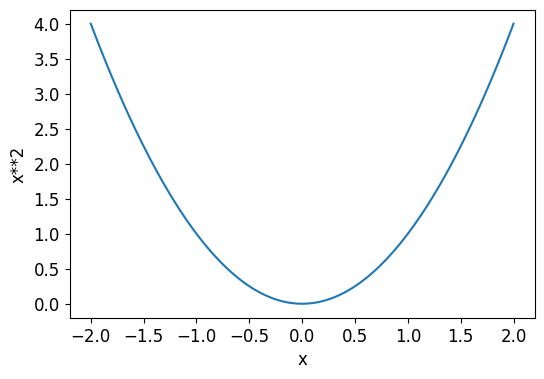

In [53]:
# 该函数的图表
plot_function(f, 'x', 'x**2')

首先为参数选择一些随机值，然后计算损失值

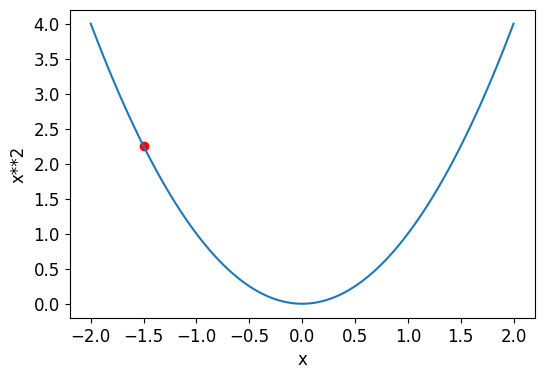

In [54]:
# 使用 plot_function 来绘制函数 f(x)=x**2 的图像，并设置了 x 轴和 y 轴的标签
plot_function(f, 'x', 'x**2')
# 在已经绘制的函数 f(x)=x**2 的图像上，标记出一个坐标为 (-1.5, 2.25) 的红色的点
plt.scatter(-1.5, f(-1.5), color='red');

上面这段代码绘制了函数 $f(x) = x^2$ 的图像，并在 x 轴值为 -1.5 的位置（对应的 y 轴值为 2.25）标记了一个红色的点。我们可以将这个红点想象成梯度下降算法的起始点，`-1.5` 是我们初始的参数值（在更复杂的模型中，这会是模型的一个权重）。

**文字讲解：**

**“Now we look to see what would happen if we increased or decreased our parameter by a little bit—the adjustment. This is simply the slope at a particular point:”**

  * **“Now we look to see what would happen if we increased or decreased our parameter by a little bit—the adjustment.”**: 这句话描述了梯度下降算法中的一个核心步骤：尝试对当前的参数（在这里是 `x` 的值，即 -1.5）进行微小的调整（增加或减少）。这个“调整”的目标是找到使损失函数（在这里是 $f(x) = x^2$）值更小的方向。
  * **“This is simply the slope at a particular point:”**: 这句话将这个“调整”的方向与函数在该点的\*\*斜率（slope）\*\*联系起来。
      * **斜率的含义:** 在函数图像上，某一点的斜率表示函数在该点处的变化率，即函数值随着自变量变化的快慢和方向。
      * **与调整方向的关系:**
          * 如果斜率为正，表示增加参数值会增加函数值，减小参数值会减小函数值。因此，为了最小化函数，我们应该朝着减小参数值的方向调整。
          * 如果斜率为负，表示增加参数值会减小函数值，减小参数值会增加函数值。因此，为了最小化函数，我们应该朝着增加参数值的方向调整。
          * 如果斜率为零，表示该点可能是局部最小值或局部最大值。

**“We can change our weight by a little in the direction of the slope, calculate our loss and adjustment again, and repeat this a few times. Eventually, we will get to the lowest point on our curve:”**

  * **“We can change our weight by a little in the direction of the slope…”**: 这描述了梯度下降的迭代过程。我们根据当前点的斜率（更准确地说是负斜率，因为我们想最小化函数）对参数进行一个小的更新。这个“一小步”的大小由一个称为\*\*学习率（learning rate）\*\*的超参数控制。
  * **“…calculate our loss and adjustment again, and repeat this a few times.”**: 在更新参数后，我们会到达曲线上的新位置。我们再次计算该点的损失值（函数值）和斜率（用于确定下一步的调整方向）。这个过程会重复多次。
  * **“Eventually, we will get to the lowest point on our curve:”**: 经过多次迭代，如果学习率设置得当，梯度下降算法最终会收敛到曲线的**最低点（全局最小值）**。对于 $f(x) = x^2$ 来说，最低点是 (0, 0)。

**“This basic idea goes all the way back to Isaac Newton, who pointed out that we can optimize arbitrary functions in this way.”**

  * **“This basic idea goes all the way back to Isaac Newton…”**: 这句话强调了梯度下降思想的悠久历史，可以追溯到伟大的科学家艾萨克·牛顿。牛顿提出了类似的方法来寻找函数的极值。
  * **“…who pointed out that we can optimize arbitrary functions in this way.”**: 牛顿指出，这种基于迭代调整参数以寻找函数最优值的方法具有广泛的适用性，可以用于优化各种不同的函数。

**“Regardless of how complicated our functions become, this basic approach of gradient descent will not significantly change. The only minor changes we will see later in this book are some handy ways we can make it faster, by finding better steps.”**

  * **“Regardless of how complicated our functions become, this basic approach of gradient descent will not significantly change.”**: 这是非常重要的一点。即使我们处理的损失函数变得非常复杂（例如，深度神经网络的损失函数），梯度下降的核心思想仍然保持不变：通过计算梯度并沿着负梯度方向更新参数来最小化损失。
  * **“The only minor changes we will see later in this book are some handy ways we can make it faster, by finding better steps.”**: 这预示着在后续的章节中，我们会学习到一些梯度下降的变体和优化技巧，例如不同的优化器（Adam, RMSprop 等）。这些方法的主要目标是更有效地选择每一步的步长（学习率）和方向，从而加速收敛到最优解的过程。

**总结：**

这段文字通过一个简单的二次函数 $f(x) = x^2$ 的例子，生动地解释了梯度下降算法的核心思想：

1.  **计算梯度（斜率）**：确定函数在当前参数值下的变化趋势。
2.  **调整参数**：沿着负梯度方向（使函数值减小的方向）微小地更新参数。
3.  **迭代**：重复这个过程，逐步接近函数的最小值。

这段文字还强调了梯度下降思想的历史渊源和在优化各种复杂函数中的普适性，并预告了后续将学习更高级的优化技巧。

## 计算梯度

首先需要知道导数的概念。

导数的关键点是：对于任何函数，例如我们在上一节中看到的二次函数，我们都可以计算其导数。导数是另一个函数。它计算的是更改，而不是值。例如，值 3 处的二次函数导数告诉我们函数在值 3 处的变化速度。当我们知道我们的函数将如何变化时，我们就知道我们需要做什么来使其更小。这就是机器学习的关键：有办法改变函数的参数以使其更小。微积分为我们提供了一个计算捷径，即导数，它让我们可以直接计算函数的梯度。

一个模型通常有很多“权重”需要调整，所以计算出来的“梯度”不是一个数字，而是一组数字（一个向量）。**这个向量中的每个数字都对应一个参数，它告诉我们应该如何调整这个参数才能让损失函数下降。**

利用 PyTorch 能够自动计算几乎任何函数的导数。

首先，让我们选择一个我们想要梯度的张量值：

In [3]:
xt = tensor(3.).requires_grad_()

* `tensor(3.)`: 创建一个 PyTorch 的张量（可以简单理解为可以进行数学运算的数字），值为 3.0。
* `.requires_grad_()`: **这行代码是关键！** 它告诉 PyTorch：“嘿，我要计算这个变量 `xt` 相关的梯度。请你记住所有涉及到 `xt` 的计算过程，以便之后能告诉我 `xt` 的微小变化会对最终结果产生什么影响。”这就像给这个变量打上一个“追踪”的标签。


In [7]:
# f(x) = x ** 2
yt = f(xt)
yt

tensor(9., grad_fn=<PowBackward0>)

* `def f(x): return x**2`: 定义了一个简单的函数 $f(x) = x^2$，这可以看作是我们简化的“损失函数”。
* `yt = f(xt)`: 使用我们标记了需要计算梯度的变量 `xt` 来计算函数值。PyTorch 不仅会计算出结果（9.0），还会记住这个计算过程，因为它知道我们后面可能需要计算梯度。

In [8]:
yt.backward()

* `.backward()`: **这行代码告诉 PyTorch：“好了，我已经完成了所有我想要计算的操作（这里只有一个 `f(xt)`），现在请你帮我计算 `yt`（我们的“损失”）关于所有设置了 `requires_grad_()` 的变量（这里是 `xt`）的梯度。”** “backward” 这个词指的是“反向传播”，这是在神经网络中计算梯度的常用方法，它从最终的输出（损失）开始，向后计算每一层的梯度。你可以暂时把它理解为“计算梯度”的指令。


In [9]:
xt.grad

tensor(6.)

* `.grad`: 这行代码用于查看我们之前标记的变量 `xt` 的梯度值。对于函数 $f(x) = x^2$，它的导数是 $2x$。当 $x=3$ 时，导数是 $2 * 3 = 6$。PyTorch 计算出的结果正是 `tensor(6.)`。这意味着，如果稍微增加 `xt` 的值，`yt` 的值会以当前速率的 6 倍增加；如果稍微减小 `xt` 的值，`yt` 的值会以当前速率的 6 倍减小。因此，为了减小 `yt`（我们的“损失”），我们应该朝着减小 `xt` 的方向调整。



重复前面的步骤，但使用函数的 vector 参数

In [10]:
xt = tensor([3.,4.,10.]).requires_grad_()
xt

tensor([ 3.,  4., 10.], requires_grad=True)

将 sum 添加到函数中，以便它可以接受一个向量（即 rank-1 张量），并返回一个标量（即 rank-0 张量）

In [11]:
def f(x): return (x**2).sum()

yt = f(xt)
yt

tensor(125., grad_fn=<SumBackward0>)

In [12]:
yt.backward()
xt.grad

tensor([ 6.,  8., 20.])

梯度只告诉我们调整参数的**方向**，但不直接告诉我们应该调整**多少**。梯度很大可能意味着离最优值还比较远，需要较大的调整；梯度很小可能意味着接近最优值，需要较小的调整。实际的调整步长还需要结合**学习率**等超参数来确定。


PyTorch 的自动梯度计算功能就像一个强大的工具，它通过记住计算过程和运用微积分的原理，能够快速地告诉我们模型中每个参数应该如何调整，才能使模型的预测结果更接近真实值，从而实现“学习”的目标。我们不需要手动计算复杂的导数，只需要告诉 PyTorch 哪些变量需要计算梯度，然后让它自动完成剩下的工作。这大大简化了深度学习模型的训练过程。

## 使用学习率单步执行


决定如何根据梯度值更改参数是深度学习过程的重要组成部分。几乎所有方法都从将梯度乘以某个小数字（称为学习率 （LR））的基本概念开始。学习率通常是 0.001 到 0.1 之间的数字，尽管它可以是任何值。通常，人们只是通过尝试几次来选择学习率，并在训练后找到最佳模型（我们将在本书后面向您展示一种更好的方法，称为学习率查找器 ）。选择学习率后，您可以使用这个简单的函数调整参数：

In [63]:
#w -= gradient(w) * lr

NameError: name 'w' is not defined


* **`w`**: 代表模型的一个参数（例如，神经网络中的一个权重）。你可以把它看作我们机器上的一个可以调整的“旋钮”。我们的目标是找到让机器输出最优结果的“旋钮”的最佳位置。

* **`gradient(w)`**: 这是一个函数，它计算出损失函数（衡量模型“坏”的程度）关于参数 `w` 的**梯度**。
    * **梯度**告诉我们，如果稍微改变 `w` 的值，损失函数会如何变化。
    * 如果梯度是正的，增加 `w` 会增加损失；如果梯度是负的，增加 `w` 会减小损失。
    * 梯度的大小表示这种变化的剧烈程度。

    你可以把 `gradient(w)` 看作一个“指南针”，它告诉我们应该朝哪个方向调整旋钮 `w` 才能让模型的“坏”程度降得最快。

* **`lr` (learning rate)**: 这是一个很小的正数（例如 0.001, 0.01, 0.1）。它决定了我们沿着梯度所指的方向调整参数 `w` 的**步长大小**。
    * **学习率**就像我们转动“旋钮”的幅度。如果学习率很大，我们一次转动很多；如果学习率很小，我们一次只转动一点点。

* **`*`**: 乘法运算符。我们将梯度乘以学习率，得到实际的调整量。这就像指南针告诉我们方向，学习率告诉我们走多远。

* **`-=`**: 减法赋值运算符。`w -= gradient(w) * lr` 的意思是：将 `w` 的当前值减去 `gradient(w) * lr` 的结果，并将新的结果赋值给 `w`。

**用“下山”的比喻：**

* `w` 是你在山上的位置（一个维度，简化理解）。
* `gradient(w)` 指向当前位置山坡最陡峭的**上升**方向。
* `-gradient(w)` 指向当前位置山坡最陡峭的**下降**方向（我们想要去的方向）。
* `lr` 是你下山时每一步迈出的大小。
* `gradient(w) * lr` 是你这一次下山要移动的实际距离。
* `w -= gradient(w) * lr` 就是你从当前位置 `w` 向下山方向移动了一步，到达新的位置 `w`。

**总结：**

这行代码实现了梯度下降算法中的一个核心迭代步骤：

1.  计算当前参数 `w` 的梯度，得到调整的方向和幅度。
2.  乘以学习率 `lr` 来控制每次调整的步长。
3.  从当前参数 `w` 的值中减去这个调整量，将 `w` 向着损失函数减小的方向更新。

通过不断重复这个“计算梯度 -> 调整参数”的过程，模型就能逐步“学习”到更好的参数值，从而提高性能。学习率的选择至关重要，它决定了模型收敛的速度和稳定性。

## 端到端随机梯度下降示例

端到端随机梯度下降 (End-to-End Stochastic Gradient Descent, End-to-End SGD) 通常指的是在**端到端**的深度学习模型训练过程中使用**随机梯度下降 (Stochastic Gradient Descent, SGD)** 优化算法。

为了更好地理解这个概念，我们先分别解释一下“端到端”和“SGD”：

**随机梯度下降 (SGD)**

* 是一种迭代优化算法，广泛应用于机器学习和深度学习中，用于最小化损失函数。
* 与传统的梯度下降算法不同，SGD 在每次迭代中**随机选择一个或少量**数据样本来计算梯度，并根据这个（随机的）梯度来更新模型参数。
* 这样做的好处是每次迭代的计算成本大大降低，尤其是在处理大规模数据集时，可以更快地进行参数更新，加速模型收敛。
* 由于每次使用的梯度是随机的，所以损失函数下降的过程会呈现出一定的随机性（波动），但总体趋势是向最小值靠近。

**端到端 (End-to-End)**

* 在深度学习中，端到端指的是**直接从原始输入数据映射到最终输出结果**的模型训练方式，中间尽可能少地进行人为的特征工程或复杂的中间处理步骤。
* 这种方法训练一个单一的神经网络来完成整个任务，而不是将任务分解成多个独立的模块并分别训练。
* 例如，在图像识别中，端到端模型直接以原始像素作为输入，输出识别结果（类别标签），模型内部的网络结构会自动学习提取有用的特征。
* 端到端学习的优势在于可以减少人工干预，让模型自己学习最优的特征表示，并且能够更好地捕捉输入和输出之间的复杂关系。

**端到端 SGD 的含义**

将两者结合起来，“端到端 SGD” 就是指：

* 我们训练一个**端到端**的深度学习模型，这个模型直接完成从输入到输出的映射。
* 在训练这个模型的过程中，我们使用 **SGD** 优化算法来更新模型的参数。这意味着在每次迭代中，我们随机抽取一个或少量训练样本，计算模型在该样本上的损失梯度，并利用这个梯度来更新整个模型的参数，从而逐步优化端到端模型的性能。

**总结来说，端到端 SGD 是一种常见的深度学习模型训练方法，它结合了端到端学习的思想和 SGD 优化算法的效率，使得模型能够直接从原始数据学习并快速收敛到较好的性能。**

从一个简单的综合示例模型开始。想象一下，您正在测量过山车越过驼峰顶部时的速度。它开始得很快，然后随着上山而变慢;它在顶部会最慢，然后在下坡时会再次加速。您想要构建一个速度如何随时间变化的模型。如果您在 20 秒内每秒手动测量一次速度，它可能如下所示：

In [13]:
time = torch.arange(0,20).float();
time

tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14., 15., 16., 17., 18., 19.])

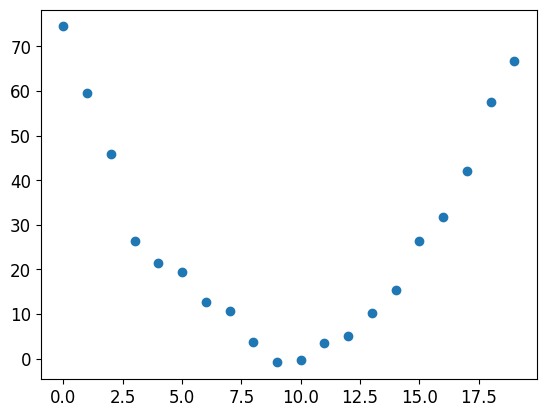

In [14]:
speed = torch.randn(20)*3 + 0.75*(time-9.5)**2 + 1
plt.scatter(time,speed);

这段代码使用 PyTorch 生成了一些模拟数据，并使用 `matplotlib.pyplot` (通过 `plt` 别名导入) 将这些数据点绘制成散点图。让我们逐步解释：

1.  **`speed = torch.randn(20)*3 + 0.75*(time-9.5)**2 + 1`**

    * **`torch.randn(20)`**: 这会生成一个包含 20 个从标准正态分布（均值为 0，标准差为 1）中随机采样得到的浮点数的 PyTorch 张量。你可以把它想象成 20 个随机的“噪声”值。
    * **`* 3`**: 将上面生成的每个随机数乘以 3。这会放大噪声的幅度，使得数据的随机性更明显。
    * **`(time-9.5)**2`**:
        * `time`: 这是我们在上一行代码中创建的张量，包含了从 0.0 到 19.0 的 20 个连续浮点数，可以理解为时间序列。
        * `time - 9.5`: 将 `time` 张量中的每个元素减去 9.5。这会将时间的中心点平移到 9.5 附近。
        * `** 2`: 对平移后的每个时间值进行平方运算。这会生成一个抛物线形状的数值序列，中心在 `time = 9.5` 附近。
    * **`0.75 * (...)`**: 将上面计算得到的抛物线数值序列中的每个元素乘以 0.75，调整抛物线的陡峭程度。
    * **`+ 1`**: 将前面所有计算结果的每个元素都加上 1，相当于将整个 `speed` 张量的值向上平移 1。
    * **`+`**: 最后，将乘以 3 的随机噪声张量与形状为抛物线的张量相加。

    **总而言之，这行代码创建了一个名为 `speed` 的 PyTorch 张量，它包含了 20 个模拟的速度值。这些速度值是基于一个以时间 `time` 为输入的二次函数（抛物线形状）叠加了一些随机噪声生成的。** 这个二次函数项 `0.75*(time-9.5)**2 + 1` 定义了速度的基本趋势，而 `torch.randn(20)*3` 则引入了随机波动。

2.  **`plt.scatter(time, speed)`**

    * **`plt`**: 这是 `matplotlib.pyplot` 模块的常用别名，用于进行绘图操作。
    * **`plt.scatter(x, y)`**: 这是一个 `matplotlib` 函数，用于绘制散点图。它将 `x` 轴上的值（在这里是 `time` 张量）和 `y` 轴上的对应值（在这里是 `speed` 张量）以点的形式在图上显示出来。

    **因此，这行代码使用 `matplotlib` 绘制了一个散点图，其中 x 轴是 `time` 张量的值（从 0 到 19），y 轴是 `speed` 张量的值（基于抛物线趋势加上随机噪声）。** 你会在图上看到 20 个离散的点，它们大致呈现出抛物线的形状，但由于随机噪声的存在，这些点不会完全落在一条完美的抛物线上。

**这段代码的目的是生成一些具有一定趋势（二次函数）和随机性的模拟数据，用于后续演示机器学习模型的训练过程，例如如何用模型去拟合这种非线性关系。**



#### 什么是均值，标准差

**想象一下有一群小球，它们散落在一条线上。**

* **均值 (Mean):** 就像这群小球的**平均位置**或者**中心点**在哪里。如果均值为 0，就意味着这些随机生成的小球的中心位置在 0 这个点上。有些小球会落在 0 的左边（负值），有些会落在 0 的右边（正值），但它们的平均位置是 0。

* **标准差 (Standard Deviation):** 就像这些小球**散开的程度**有多大。

    * **标准差为 1** 意味着这些小球**相对集中**在均值 0 的附近。大部分小球会落在距离 0 不太远的地方，比如 -1 到 +1 的范围内的比较多。离 0 很远的小球就比较少。

    * 如果标准差很大（比如是 3），那么这些小球就会散得很开，很多小球会落在远离均值 0 的地方，正负几甚至十几都有可能。

**对应到 `torch.randn(20)`:**

`torch.randn(20)` 这个 PyTorch 函数会生成 20 个数字，这些数字就像我们想象中的小球的位置。这些数字的分布符合一个叫做**标准正态分布**的特性，这个分布的特点就是：

* **均值为 0:** 生成的这 20 个数字的平均值会非常接近 0（如果你生成更多的数据，平均值会越来越接近 0）。也就是说，正数和负数出现的概率以及它们的大小是相对平衡的。
* **标准差为 1:** 生成的这些数字的波动程度或分散程度是“标准”的。大约 68% 的数字会落在 -1 到 +1 的范围内，大约 95% 的数字会落在 -2 到 +2 的范围内，以此类推。

**简单来说：**

`torch.randn(20)` 创造了一组“围绕 0 散落，且散落程度适中”的 20 个随机数。这个“适中”的散落程度就是由标准差 1 来衡量的。

**为什么在代码中要乘以 3？**

在代码 `torch.randn(20) * 3` 中乘以 3，就像把我们想象中的小球散落的范围放大了 3 倍。这时，数据的均值仍然是 0（0 乘以 3 还是 0），但是标准差变成了 3。这意味着生成的随机数会更加分散，更有可能出现绝对值较大的数字。


我们添加了一些随机噪声，因为手动测量并不精确。这意味着回答这个问题并不容易：过山车的速度是多少？使用 SGD，我们可以尝试找到与我们的观察结果匹配的函数。我们不能考虑所有可能的函数，所以让我们猜测它将是二次函数;即，形式为 A*（时间**2）+（B*时间）+C 的函数。这个函数就是一个非常简单的、只有一层的神经网络模型。它将输入 t 转换成一个预测值

In [15]:
# 定义一个名为 f 的函数作为我们的模型（或预测函数）

# params代表模型的参数，一个包含三个元素的张量
def f(t, params):
    # 通过解包操作 a, b, c = params 分离三个系数
    a,b,c = params
    return a*(t**2) + (b*t) + c

我们将寻找适合数据的最佳可想象函数的问题限制为寻找最佳二次函数 。这大大简化了问题，因为每个二次函数都完全由三个参数 a、b 和 c 定义。因此，要找到最佳二次函数，我们只需要找到 a、b 和 c 的最佳值。


如果我们能为二次函数的三个参数解决这个问题，我们将能够将相同的方法应用于其他具有更多参数的更复杂的函数，例如神经网络。让我们先找到 f 的参数，然后我们回来对带有神经网络的 MNIST 数据集做同样的事情。

我们首先需要定义我们所说的“最好”是什么意思。我们通过选择损失函数来精确定义这一点，该函数将返回基于预测和目标的值，其中函数的较低值对应于“更好”的预测。当预测更准确时，损失函数返回较低的值非常重要，因为我们之前定义的 SGD 过程将尝试最小化这种损失。对于连续数据，通常使用均方误差 ：

In [16]:
# 定义一个损失函数
# preds: 代表模型的预测值（f(t, params) 的输出）
# targets: 代表真实的、期望的目标值（数据的真实标签）
def mse(preds, targets):
  # 返回均方误差（Mean Squared Error, MSE）损失函数的计算公式
  return ((preds-targets)**2).mean()

**步骤 1：初始化参数**

首先，将参数初始化为随机值，并使用 requires_grad_ 告诉 PyTorch 我们要跟踪它们的梯度：

In [17]:
# 随机模型的初始参数 a, b, c
params = torch.randn(3).requires_grad_()

In [18]:
# 在训练过程中，params 张量的值会不断被更新。orig_params 的作用是保存 params 的初始值
orig_params = params.clone()

**步骤 2：计算预测**


In [19]:
preds = f(time, params)


创建一个小函数来查看我们的预测与目标的接近程度，然后看一下

In [20]:
def show_preds(preds, ax=None):
    if ax is None: ax=plt.subplots()[1]
    ax.scatter(time, speed)
    ax.scatter(time, to_np(preds), color='red')
    ax.set_ylim(-300,100)

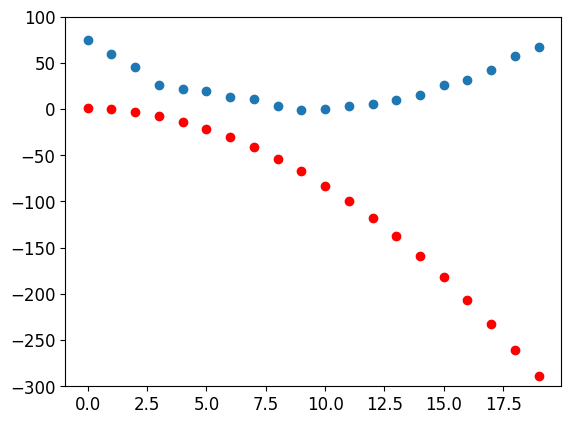

In [21]:
show_preds(preds)

这看起来不是很接近——我们的随机参数表明过山车最终会倒退，因为我们的速度是负的！

**步骤 3：计算损失**

In [22]:
loss = mse(preds, speed)
loss

tensor(25823.8086, grad_fn=<MeanBackward0>)

我们现在的目标是改善这一点。要做到这一点，我们需要知道梯度

**步骤 4: 计算梯度**

计算参数需要如何变化的近似值

In [24]:
loss.backward()
# 存储张量 params 相对于某个标量损失函数 (loss) 的梯度的属性
# 是用来实际指导模型参数如何调整以降低损失的关键信息
params.grad

tensor([-53195.8633,  -3419.7148,   -253.8908])

In [25]:
params.grad * 1e-5

tensor([-0.5320, -0.0342, -0.0025])

我们可以使用这些梯度来改进我们的参数。我们需要选择一个学习率

In [27]:
params

tensor([-0.7658, -0.7506,  1.3525], requires_grad=True)

**步骤 5: 更新权重**

根据刚刚计算的梯度更新参数

In [28]:
# 手动实现梯度下降优化算法的核心步骤

# 定义了一个学校率
lr = 1e-5
# 参数更新的核心步骤，它实现了梯度下降算法
params.data -= lr * params.grad.data
# 梯度清零 (zeroing the gradients) 的操作
params.grad = None

看看损失是否有所改善

In [29]:
preds = f(time,params)
mse(preds, speed)

tensor(5435.5356, grad_fn=<MeanBackward0>)

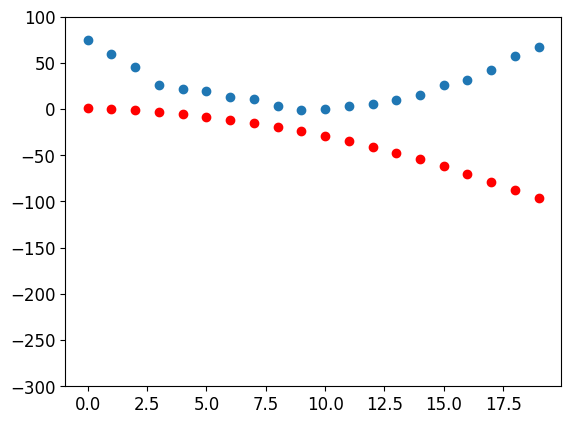

In [31]:
show_preds(preds)

需要重复几次，因此我们将创建一个函数来应用一个步骤

In [32]:
# 封装了机器学习模型训练中的一个完整优化循环的单次迭代
def apply_step(params, prn=True):
    preds = f(time, params)
    loss = mse(preds, speed)
    loss.backward()
    params.data -= lr * params.grad.data
    params.grad = None
    if prn: print(loss.item())
    return preds

**步骤 6: 重复该过程**

In [114]:
for i in range(10):
  apply_step(params)

5017.7001953125
1526.1304931640625
865.4158935546875
740.3851318359375
716.722412109375
712.241455078125
711.390380859375
711.2261962890625
711.1917724609375
711.18212890625


In [115]:
# 重置模型的参数到初始状态，同时确保它们是可训练的。
params = orig_params.detach().requires_grad_()

上面这段代码将params 重置到了初始状态，方面下面调用。

但是为什么不像orig_params 一样clone()出来，而用detach()呢？

**它们的核心区别在于对计算图和梯度追踪的影响**。

---

### `clone()` 方法

* **作用：** 创建一个张量的**副本**。这个副本拥有与原始张量相同的数值、形状和数据类型。
* **计算图：**
    * `clone()` 操作**会被记录到计算图中**。
    * 这意味着，如果你对 `clone()` 产生的副本执行操作，并且这个副本的 `requires_grad` 为 `True`，那么 PyTorch 会追踪这些操作，并且在反向传播时，**梯度会流回原始张量**。
    * 换句话说，副本的梯度计算是依赖于原始张量的。
* **梯度追踪：**
    * 如果原始张量的 `requires_grad` 为 `True`，那么 `clone()` 得到的副本的 `requires_grad` 也会**默认为 `True`**。
    * 对副本进行的操作会影响到原始张量的梯度。
* **示例：**
    ```python
    import torch

    a = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
    b = a.clone()  # b是a的副本，且b.requires_grad默认为True
    print(f"a: {a}, requires_grad={a.requires_grad}")
    print(f"b: {b}, requires_grad={b.requires_grad}")

    c = b * 2
    c.sum().backward() # 梯度会通过b流回a

    print(f"a.grad: {a.grad}") # a.grad 会是 tensor([2., 2., 2.])
    print(f"b.grad: {b.grad}") # b.grad 默认为None (因为b不是叶子节点，梯度会传到a)
    ```
    * 在这个例子中，`b` 是 `a` 的一个副本，`b` 的操作会影响 `a` 的梯度。

---

### `detach()` 方法

* **作用：** 从当前的计算图中**分离**张量，并创建一个新的张量。
* **计算图：**
    * `detach()` 操作**不会被记录到计算图中**。
    * 这意味着，`detach()` 产生的张量是一个“新的起点”，它与原始张量的计算历史**完全脱钩**。
    * 对 `detach()` 产生的张量执行的任何操作，其梯度**不会流回原始张量**，原始张量也不会受到这个新张量操作的影响。
* **梯度追踪：**
    * `detach()` 得到的张量的 `requires_grad` 属性会**默认为 `False`**。
    * 即使原始张量的 `requires_grad` 是 `True`，分离出来的张量通常也需要你**显式地再次调用 `requires_grad_()`** 才能使其再次可追踪梯度。
* **示例：**
    ```python
    import torch

    a = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
    b = a.detach() # b是a的分离副本，且b.requires_grad默认为False
    print(f"a: {a}, requires_grad={a.requires_grad}")
    print(f"b: {b}, requires_grad={b.requires_grad}")

    # 如果要让b也参与梯度计算，需要显式设置
    b.requires_grad_(True)
    c = b * 2
    c.sum().backward() # 梯度只会流回b，不会流回a

    print(f"a.grad: {a.grad}") # a.grad 会是 None
    print(f"b.grad: {b.grad}") # b.grad 会是 tensor([2., 2., 2.])
    ```
    * 在这个例子中，`b` 是从 `a` 分离出来的，`b` 的操作不再影响 `a` 的梯度。

---

### 主要区别总结

| 特征           | `clone()`                                    | `detach()`                                |
| :------------- | :------------------------------------------- | :---------------------------------------- |
| **计算图** | **保留**计算图连接，操作会被记录。          | **切断**计算图连接，操作不会被记录。      |
| **梯度流动** | 梯度会从副本**流回原始张量**。              | 梯度**不会流回原始张量**。                |
| **`requires_grad`** | **继承**原始张量的 `requires_grad` 状态（如果原始是 `True`，副本也是 `True`）。 | 默认为 `False`（即使原始是 `True`）。需要显式调用 `requires_grad_()` 来启用。 |
| **应用场景** | 需要在计算图中保留依赖关系，但又不想直接修改原始张量。例如，在反向传播时需要梯度回溯。 | 需要获取张量的数值，但又不希望其操作影响计算图，也不需要为这些操作计算梯度。例如，将模型输出用于指标计算，或者冻结部分模型参数。 |

### 何时使用哪个？

* **使用 `clone()`：**
    * 当你需要一个张量的副本，并且你希望这个副本的任何操作都能够**通过反向传播影响到原始张量**（即，你希望在计算图中保留它们的依赖关系）。
    * 例如，在构建自定义层时，你可能想复制某些输入张量以便进行某些中间操作，但又希望这些操作的梯度能够正确地传播回去。
    * 当你想要一个张量的可变副本，同时保留其在计算图中的历史。

* **使用 `detach()`：**
    * 当你需要一个张量的数值，但**不希望它参与梯度计算**，也不希望它影响到计算图中的其他张量。
    * **冻结参数**：将某个模型的输出作为另一个模型的输入，但不想为第一个模型的参数计算梯度。
    * **评估模式**：在验证或测试阶段，你只需要模型的预测值，不需要计算梯度来更新参数。
    * **可视化或日志记录**：当你只想获取张量的数值进行打印或绘图，而不想让这些操作影响训练过程或计算图。
    * **重置参数**：像你例子中的 `orig_params.detach().requires_grad_()`，它用于获取原始参数的数值，但切断与 `orig_params` 的计算图关联，然后将新的 `params` 标记为可追踪梯度。

理解 `detach()` 和 `clone()` 的区别对于正确构建和训练 PyTorch 模型至关重要，尤其是在处理复杂的计算图和梯度流时。

损失正在下降！但是，仅查看这些损失数字掩盖了这样一个事实，即每次迭代都代表正在尝试的完全不同的二次函数，以寻找最佳的二次函数。如果我们不是打印出损失函数，而是在每一步都绘制函数，那么我们可以直观地看到这个过程。然后，我们可以看到形状如何接近我们数据的最佳二次函数

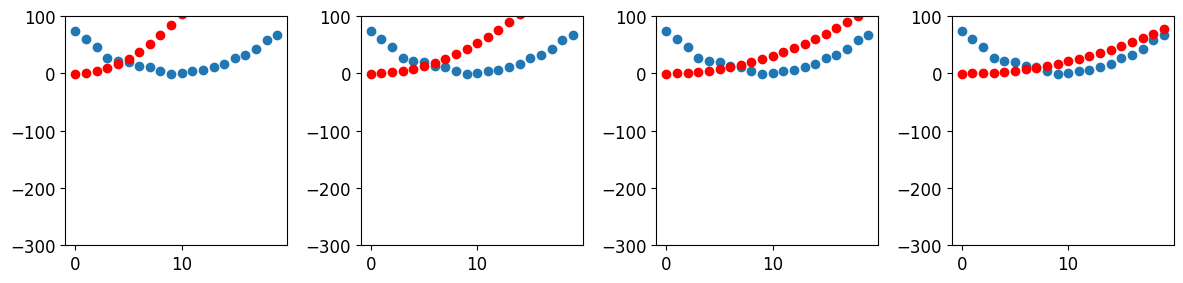

In [116]:
_,axs = plt.subplots(1,4,figsize=(12,3))
for ax in axs: show_preds(apply_step(params, False), ax)
plt.tight_layout()

**步骤 7: 停止**

**总结梯度下降**

一开始，我们模型的权重可以是随机的（ 从头开始训练），也可以来自预训练的模型（ 迁移学习 ）。在第一种情况下，我们从输入中获得的输出与我们想要的结果没有任何关系，即使在第二种情况下，预训练模型很可能不会很好地完成我们针对的特定任务。因此，模型需要学习更好的权重。

> **迁移学习 (transfer learning)**: 模型的权重来自一个**已经训练过的模型 (pretrained model)**。这个预训练模型可能在一个非常大的数据集上执行过类似或相关的任务。然后，我们把这些学到的权重“借用”过来，作为我们新模型的初始权重。这种方法被称为 "**迁移学习 (transfer learning)**"

首先使用**损失函数**将模型提供给我们的输出与我们的目标（我们已经标记了数据，因此我们知道模型应该给出什么结果）进行比较，该函数返回一个我们希望通过提高权重来尽可能降低的数字。为此，我们从训练集中获取一些数据项（例如图像）并将它们提供给我们的模型。我们使用损失函数比较相应的目标，我们得到的分数告诉我们预测有多错误。然后，我们稍微改变权重以使其稍微好一些

为了找到如何更改权重以使损失更好，我们使用微积分来计算梯度 。（实际上，我们让 PyTorch 为我们做这件事！让我们考虑一个类比。想象一下，你迷失在山中，你的车停在最低点。要找到回到它的路，你可能会随机地徘徊，但这可能没有多大帮助。既然你知道你的车在最低点，你最好还是下坡。通过始终朝着最陡峭的下坡方向迈出一步，您最终应该会到达目的地。我们使用梯度的大小（即斜率的陡峭程度）来告诉我们要采取多大的步长;具体来说，我们将梯度乘以我们选择的数字（称为学习率 ）来确定步长。然后我们迭代 ，直到到达最低点，也就是我们的停车场，然后我们就可以停下来了。



### 损失函数

我们已经有了自变量 x——这些是图像本身。我们将它们全部连接到一个张量中，并将它们从矩阵列表（3 阶张量）更改为向量列表（2 阶张量）。我们可以使用 view 来做到这一点，view 是一种 PyTorch 方法，可以在不改变其内容的情况下改变张量的形状。-1 是一个特殊的 view 参数，表示 “使这个轴尽可能大以适应所有数据”：

In [117]:
train_x = torch.cat([stacked_threes, stacked_sevens]).view(-1, 28*28)

**代码解释**

这行代码是深度学习中**准备训练数据**的关键步骤之一，它将不同类别的图像数据合并成一个大的训练集，并将其形状调整为适合模型输入的格式。

### 1. `torch.cat([stacked_threes, stacked_sevens])`

* **`stacked_threes`**: 这是包含所有归一化后的数字3图像的张量。其形状为 `(N_3, H, W)`，其中 `N_3` 是数字3的图像数量，`H` 是高度（28），`W` 是宽度（28）。
* **`stacked_sevens`**: 这是包含所有归一化后的数字7图像的张量。其形状为 `(N_7, H, W)`，其中 `N_7` 是数字7的图像数量，`H` 是高度（28），`W` 是宽度（28）。
* **`torch.cat([...])`**: 这是 PyTorch 中的一个函数，用于**沿着现有维度连接（concatenate）**一系列张量。
    * `[stacked_threes, stacked_sevens]` 是一个包含要连接的张量的列表。
    * 默认情况下（或者如果未指定 `dim` 参数），`torch.cat()` 会沿着**第一个维度（即维度 0）**进行连接。
    * **连接方式**：它会将 `stacked_sevens` 的所有图像添加到 `stacked_threes` 的所有图像的后面。
    * **结果形状**：连接后的张量形状将是 `(N_3 + N_7, H, W)`。例如，如果 `N_3=6000`, `N_7=5800`，那么结果张量的形状就是 `(11800, 28, 28)`。
    * **作用**：这一步将数字3和数字7的训练图像合并到一个大的张量中，形成了所有训练图像的集合。

### 2. `.view(-1, 28*28)`

* **`.view()`**: 这是 PyTorch 张量的一个方法，用于**改变张量的形状（reshape）**，同时保持元素总数不变。
    * `view()` 操作是**零拷贝 (zero-copy)** 的，意味着它不会创建新的内存，只是改变了张量在内存中的视图。
    * **`-1`**：这是一个特殊的占位符。当在 `view()` 中使用 `-1` 时，PyTorch 会**自动计算该维度的大小**，以确保张量的元素总数保持不变。
    * **`28*28`**: 这表示你希望将图像的 `H`（高度）和 `W`（宽度）维度展平（flatten）为一个单一的维度。对于 28x28 的图像，这结果是 784。

* **形状调整**：
    * 原始形状是 `(N_3 + N_7, H, W)`，例如 `(11800, 28, 28)`。
    * 我们希望将其重塑为 `(批次大小, 展平后的特征数量)`。
    * `view(-1, 28*28)` 意味着：
        * 让 PyTorch 自动计算第一个维度的大小（这将是 `N_3 + N_7`）。
        * 将第二个维度（H）和第三个维度（W）合并成一个维度，其大小是 `H * W`。
    * **结果形状**：最终 `view()` 操作会生成一个形状为 `(N_3 + N_7, H * W)` 的二维张量。例如，`train_x` 的形状将是 `(11800, 784)`。

* **作用**：
    * **展平图像**：将每张 28x28 的二维图像展平为一个包含 784 个像素值的一维向量。这对于许多全连接层（线性层）的神经网络来说是必需的，因为它们通常期望接收一维的输入特征向量。
    * **准备批处理数据**：将所有图像整理成一个标准的二维矩阵，其中每行是一个样本（一张展平后的图像），每列是一个特征（一个像素）。这个格式是训练机器学习模型时最常见的数据输入格式。

### 综合解释

`train_x = torch.cat([stacked_threes, stacked_sevens]).view(-1, 28*28)` 这行代码完成了以下关键的数据预处理步骤：

1.  **数据合并**：将所有代表数字3和数字7的图像张量合并到一起，形成一个包含所有训练样本的单一三维张量。
2.  **数据展平与重塑**：将每个三维图像张量（例如 28x28）展平为一维向量（784个像素），并将所有这些展平后的图像堆叠成一个二维张量。这个二维张量的每一行是一个训练样本，每一列代表图像的一个像素特征。

最终得到的 `train_x` 张量就是你的模型将要接收的**特征输入 (input features)**。它包含了所有图像的像素数据，以模型可以理解和处理的格式组织。



### 1. 为什么要把3和7拼接起来？

`torch.cat([stacked_threes, stacked_sevens])`

* **目的**：将不同类别的训练数据**合并成一个统一的训练集**。
* **原因**：
    1.  **统一输入格式**：无论是数字3的图片还是数字7的图片，对于模型来说，它们都是“输入数据”。模型在训练时需要一个统一的输入张量，而不是分别处理两类数据。拼接起来可以一次性喂给模型一个大的批次（或在后续分批次时）。
    2.  **便于数据处理**：后续的数据加载器（DataLoader）和训练循环会期望一个统一的数据集。将所有训练样本放在一个大张量中，可以更方便地进行随机抽样、批处理等操作。
    3.  **支持多分类**：即使现在是二分类（3和7），这种拼接方式也自然地扩展到多分类问题。如果你有10个类别的数字（0-9），你也会把所有这10个类别的图片都拼接起来，形成一个更大的训练集。
    4.  **模型是通用的**：模型本身并不知道它在区分的是3还是7。它只是学习如何从输入的784个像素中提取特征，然后输出一个判断值。所以，喂给它什么数据，它就去学习什么数据的规律。

简而言之，拼接是为了创建一个**完整的、统一的训练数据特征集**，供模型学习使用。

---

### 2. 如果训练数据类型很多也都拼接起来？

**是的，如果训练数据类型很多（例如 MNIST 数据集中的 0-9 这 10 种数字），你也会把它们全部拼接起来。**

例如，如果你有 `stacked_zeros`, `stacked_ones`, ..., `stacked_nines`，那么 `train_x` 的创建方式会是：

```python
train_x = torch.cat([stacked_zeros, stacked_ones, ..., stacked_nines]).view(-1, 28*28)
```

然后对应的 `train_y` 也会包含 0 到 9 的所有标签。这是深度学习模型处理多分类任务的**标准做法**。

---

### 3. `view(-1, 28*28)` 把每张 28x28 的图像展平（flatten）成一个 784 像素的一维向量，这个一维向量的内容是什么样子？

假设我们有一张 28x28 的灰度图像，它由像素值组成（通常是 0 到 255 之间的整数，或归一化后的浮点数）。

例如，一张非常小的 2x2 图像：

```
像素值矩阵：
[[10, 20],
 [30, 40]]
```

当它被展平为一维向量时，通常会按照**行优先 (row-major)** 的顺序进行。也就是说，先是第一行的所有像素，然后是第二行的所有像素，依此类推。

所以，对于上面的 2x2 图像，展平后的**一维向量的内容**会是：
`[10, 20, 30, 40]`

对于 28x28 的图像：
* 它包含 $28 \times 28 = 784$ 个像素。
* 展平后，这个 784 像素的一维向量将包含**原图像中所有像素的数值**，按照从左到右、从上到下的顺序排列。

**内容示例（部分）：**

如果原始图像的第一行是 `[p1, p2, ..., p28]`，第二行是 `[p29, p30, ..., p56]`，等等。
那么展平后的一维向量会是：
`[p1, p2, ..., p28, p29, p30, ..., p56, ..., p784]`

---

### 4. 为什么要展平（Flatten）？

`view(-1, 28*28)` 的核心目的就是**展平图像**。

* **适应全连接层/线性层 (Fully Connected / Linear Layers) 的输入**：
    * 在最基础的神经网络（特别是只有全连接层的网络）中，每一层的神经元都与前一层的所有输出（或输入）相连接。
    * 这些全连接层（在 PyTorch 中通常是 `nn.Linear`）的输入通常期望是**一维向量**。
    * 也就是说，如果你有一个 `nn.Linear(in_features=784, out_features=...)` 的层，它就期望接收一个包含 784 个特征的向量作为输入。
    * 通过展平，我们把二维的图像数据转换成了这种适合全连接层处理的一维特征向量。

* **特征提取的早期形式**：
    * 展平可以看作是将原始像素作为最基本的特征输入到模型中。模型会从这些原始像素中学习更抽象、更高层次的特征。

* **简化模型结构**：
    * 对于简单的线性分类器或多层感知机 (MLP)，直接将图像展平是最直接的输入方式。如果图像保持二维或三维，你可能需要使用卷积层 (Convolutional Layers) 来处理其空间结构，这会使模型更复杂。

**总结一下：**

1.  **拼接**是为了将不同类别的训练数据汇集到一个大的、统一的张量中，方便后续处理和训练。
2.  **展平**是为了将每个二维图像转换为一维向量，以适应神经网络中**全连接层**（线性层）的输入要求。展平后的一维向量内容就是原图像所有像素值按顺序的排列。



In [118]:
train_y = tensor([1]*len(threes) + [0]*len(sevens)).unsqueeze(1)
train_x.shape,train_y.shape

(torch.Size([12396, 784]), torch.Size([12396, 1]))

**代码解释**

这两行代码的主要目的是**创建训练数据的标签 (labels)**，并确认特征数据和标签数据的形状匹配。

### 1. `train_y = tensor([1]*len(threes) + [0]*len(sevens)).unsqueeze(1)`

这行代码负责生成与 `train_x` 中的图像一一对应的标签。我们将数字3的图像标记为 `1`，数字7的图像标记为 `0`。

* **`len(threes)`**:
    * 获取 `threes` 列表的长度，即训练集中数字3图像的数量。
* **`[1]*len(threes)`**:
    * 这是一个 Python 列表的乘法操作。它会创建一个包含 `len(threes)` 个 `1` 的列表。
    * 例如，如果 `len(threes)` 是 6000，那么这将生成 `[1, 1, 1, ..., 1]`（总共 6000 个 1）。这代表了所有数字3图像的标签。
* **`len(sevens)`**:
    * 获取 `sevens` 列表的长度，即训练集中数字7图像的数量。
* **`[0]*len(sevens)`**:
    * 同样，这会创建一个包含 `len(sevens)` 个 `0` 的列表。
    * 例如，如果 `len(sevens)` 是 5800，那么这将生成 `[0, 0, 0, ..., 0]`（总共 5800 个 0）。这代表了所有数字7图像的标签。
* **`[1]*len(threes) + [0]*len(sevens)`**:
    * 这是两个 Python 列表的拼接操作。它会将代表数字3标签的列表和代表数字7标签的列表合并成一个大的列表。
    * 例如，结果可能是 `[1, 1, ..., 1, 0, 0, ..., 0]`，其中前面是所有 `1`（对应数字3），后面是所有 `0`（对应数字7）。
    * 这个列表的顺序与 `train_x` 中图像的顺序是**严格对应的**，因为 `train_x` 是先连接 `stacked_threes` 再连接 `stacked_sevens`。
* **`tensor(...)`**:
    * 这是 fastai 提供的函数，用于将 Python 列表（或 NumPy 数组等）转换为 PyTorch 张量。
    * **结果**：现在我们有了一个 PyTorch 张量，其形状是 `(N_3 + N_7,)`，例如 `(11800,)`。这是一个**一维张量**。
* **`.unsqueeze(1)`**:
    * 这是 PyTorch 张量的一个方法，用于在指定位置**增加一个维度**。
    * 参数 `1` 表示在**索引为 1 的位置（即第二个维度）**增加一个维度。
    * 为什么需要这样做？
        * 原始张量的形状是 `(总样本数,)`，例如 `(11800,)`。这表示一个扁平的向量。
        * 在机器学习中，尤其是处理分类任务的标签时，模型（特别是交叉熵损失函数等）通常期望标签张量是一个**二维张量**，形状为 `(批次大小, 1)`。例如，`[[1], [0], [1], ...]` 而不是 `[1, 0, 1, ...]`。增加一个维度使得每个标签被视为一个独立的“特征”维度，这符合某些 PyTorch 损失函数或模型输出的预期格式。
    * **结果**：经过 `unsqueeze(1)` 之后，`train_y` 的形状将从 `(N_3 + N_7,)` 变为 `(N_3 + N_7, 1)`。例如，`train_y` 的形状将是 `(11800, 1)`。

* **`train_y = ...`**: 这一行代码将最终生成的标签张量赋值给变量 `train_y`。

### 2. `train_x.shape, train_y.shape`

* **`train_x.shape`**:
    * 获取 `train_x` 张量的形状。我们之前已经解释过，它的形状是 `(总样本数, 展平后的像素数)`，例如 `(11800, 784)`。
* **`train_y.shape`**:
    * 获取 `train_y` 张量的形状。我们刚刚解释过，它的形状是 `(总样本数, 1)`，例如 `(11800, 1)`。
* **`,` (逗号)**:
    * Python 中，用逗号分隔多个表达式会创建一个元组，包含这些表达式的结果。

### 综合解释

这两行代码共同完成了**构建训练数据集**的关键部分：

1.  **`train_y` 的创建**：它生成了一个包含所有训练图像对应标签的 PyTorch 张量。在这个二分类问题中，数字3的图像被标记为1，数字7的图像被标记为0。`unsqueeze(1)` 操作确保了标签张量具有正确的二维形状 `(N, 1)`，这对于与模型训练和损失函数计算的兼容性至关重要。

2.  **形状验证**：`train_x.shape,train_y.shape` 这行代码用于快速检查 `train_x`（特征数据）和 `train_y`（标签数据）的形状。
    * `train_x` 的第一个维度（样本数）应该与 `train_y` 的第一个维度（样本数）**完全匹配**。例如，都是 11800。这确保了每个输入样本都有一个对应的标签，并且它们的顺序是正确的。
    * `train_x` 的第二个维度是每个样本的特征数量（784像素）。
    * `train_y` 的第二个维度通常是 1（对于单一标签的分类任务）。

这一步是监督学习中准备数据的基础，确保了模型能够接收到正确格式的输入特征和对应的真实标签，从而进行有效的训练。

**注意**

train_x.shape,train_y.shape 返回的是形状

如果要查看内容只需要直接打印张量本身：print(train_x)

注意区分

**形状 (Shape)：轮廓，结构，盒子有多大？ 你可以通过 .shape 属性来获取。**
**内容 (Content)：数据，数值，盒子里装了什么？ 你可以直接打印张量来查看。**

In [86]:
dset = list(zip(train_x,train_y))
x,y = dset[0]
x.shape,y

(torch.Size([784]), tensor([1]))

**代码解释**

这段代码主要用于**将特征数据和标签数据配对组合成一个数据集**，并演示如何从中**取出单个样本**。

### 1. `dset = list(zip(train_x,train_y))`

* **`train_x`**:
    * 这是一个 PyTorch 张量，包含所有训练图像的像素数据，形状为 `(总样本数, 展平后的像素数)`，例如 `(11800, 784)`。
    * 它代表了训练数据的**特征（features）**。
* **`train_y`**:
    * 这是一个 PyTorch 张量，包含所有训练图像对应的标签，形状为 `(总样本数, 1)`，例如 `(11800, 1)`。
    * 它代表了训练数据的**标签（labels）**。
* **`zip(train_x, train_y)`**:
    * 这是 Python 内置的 `zip()` 函数。
    * `zip()` 函数的作用是将多个可迭代对象（在这里是 `train_x` 和 `train_y`）中**对应位置的元素打包成一个个元组**，然后返回一个 `zip` 对象（这是一个迭代器）。
    * 由于 `train_x` 和 `train_y` 的第一个维度（样本数）是相同的，`zip()` 会将 `train_x` 的第一个样本（行）与 `train_y` 的第一个标签（行）配对，第二个样本与第二个标签配对，依此类推。
    * **重要**：`zip()` 是按行（样本）进行配对的。`train_x` 的每一行是一个展平的图像，`train_y` 的每一行是一个对应的标签。
* **`list(...)`**:
    * `zip()` 函数返回的是一个迭代器，它不会立即生成所有配对。为了方便查看或后续处理，我们通常会使用 `list()` 将其转换为一个**列表**。
* **`dset = ...`**:
    * 最终，`dset` 变量将成为一个列表，其中每个元素都是一个**元组 `(feature_sample, label_sample)`**。
    * `dset` 的长度将是训练样本的总数（例如 11800）。
    * 例如，`dset[0]` 将是 `(train_x[0], train_y[0])`，`dset[1]` 将是 `(train_x[1], train_y[1])`，以此类推。

### 2. `x,y = dset[0]`

* **`dset[0]`**:
    * 访问 `dset` 列表的第一个元素（索引为0）。
    * 根据 `dset` 的结构，`dset[0]` 将是一个元组，包含**第一个训练样本的特征**和**第一个训练样本的标签**。例如，它可能是 `(train_x[0], train_y[0])`。
* **`x,y = ...`**:
    * 这是一个 Python 中的**元组解包 (tuple unpacking)**。
    * 它会将 `dset[0]` 这个元组中的第一个元素赋值给变量 `x`，第二个元素赋值给变量 `y`。
    * **结果**：
        * `x` 将会是 `train_x` 中的第一行张量，形状为 `(784,)`（一个展平的图像）。
        * `y` 将会是 `train_y` 中的第一行张量，形状为 `(1,)`（一个标签）。

### 3. `x.shape,y`

* **`x.shape`**:
    * 获取变量 `x`（即第一个训练样本的特征张量）的形状。
    * **结果**：这将是 `torch.Size([784])`。这表明 `x` 是一个包含 784 个元素的**一维张量**，代表了第一个图像的展平像素。
* **`y`**:
    * 直接打印变量 `y` 的值（即第一个训练样本的标签张量）。
    * **结果**：这将打印出 PyTorch 张量的表示，例如 `tensor([1])` 或 `tensor([0])`，取决于第一个样本是数字3还是数字7。

### 综合解释

这段代码共同完成了以下任务：

1.  **构建训练数据集**：`dset = list(zip(train_x,train_y))` 将图像特征和它们的对应标签“捆绑”在一起，形成了一个易于迭代和访问的完整数据集。这是在 PyTorch 中构建 `Dataset` 对象的前身或简化形式，后续通常会传入 `DataLoader` 进行批处理。

2.  **提取单个样本**：`x,y = dset[0]` 演示了如何从这个数据集（`dset`）中方便地提取出**单个的输入特征 `x` 和其对应的真实标签 `y`**。

3.  **样本验证**：`x.shape,y` 则用于快速检查提取出的单个样本的形状和标签值，确保数据加载和配对的正确性。通过 `x.shape` 你可以看到每个图像现在是一个 784 维的向量，而 `y` 则告诉你这个向量对应的标签是什么（`1` 代表 3，`0` 代表 7）。

In [87]:
# 参考上面的创建验证集相关
valid_x = torch.cat([valid_3_tens, valid_7_tens]).view(-1, 28*28)
valid_y = tensor([1]*len(valid_3_tens) + [0]*len(valid_7_tens)).unsqueeze(1)
valid_dset = list(zip(valid_x,valid_y))

In [88]:
# 初始化模型参数
def init_params(size, std=1.0):
  return (torch.randn(size)*std).requires_grad_()

In [89]:
# 创建一个形状为 (784, 1) 的二维张量
# 这个张量被称为权重矩阵 (Weight Matrix)
weights = init_params((28*28,1))

In [90]:
# 创建一个形状为 (1,) 的一维张量
# 这个张量被称为偏置项 (Bias Term)
bias = init_params(1)

计算一张图像的预测

In [91]:
(train_x[0]*weights.T).sum() + bias

tensor([20.2336], grad_fn=<AddBackward0>)

**代码解释**

这段代码展示了**一个单一输入样本通过一个最简单的线性模型（或神经网络中的一个线性层）进行前向传播（forward pass）计算**的过程。它计算的是一个输入图像的像素值经过权重加权和偏置调整后的**输出值**。

让我们一步步分解：

---

### 1. `train_x[0]`

* **`train_x`**: 这是我们之前创建的包含所有训练图像特征的张量，形状是 `(总样本数, 展平后的像素数)`，例如 `(11800, 784)`。
* **`[0]`**: 这是索引操作，用于获取 `train_x` 中的**第一个样本**。
* **结果**: `train_x[0]` 会是一个形状为 `(784,)` 的一维张量。它代表了第一张训练图像的 784 个展平后的像素值。

---

### 2. `weights.T`

* **`weights`**: 这是我们之前初始化的权重矩阵，形状是 `(784, 1)`。
    * `784` 是输入特征的数量（像素）。
    * `1` 是输出神经元的数量。
* **`.T`**: 这是 PyTorch 张量的一个方法，用于计算张量的**转置 (Transpose)**。
    * 转置操作会交换张量的维度。
    * **结果**: `weights.T` 的形状将变为 `(1, 784)`。

**为什么需要转置？**
原始的 `weights` 形状是 `(784, 1)`，如果直接与 `train_x[0]`（形状 `(784,)`）相乘，可能会导致维度不匹配或广播行为不符合预期。将其转置为 `(1, 784)` 后，可以方便地进行逐元素乘法，或者为后续的矩阵乘法做准备。

---

### 3. `train_x[0]*weights.T`

* 这是两个张量之间的**逐元素乘法 (Element-wise Multiplication)**。
* `train_x[0]` 的形状是 `(784,)`。
* `weights.T` 的形状是 `(1, 784)`。
* 在 PyTorch 中，当两个张量的形状不同但兼容时，会自动应用**广播 (Broadcasting)** 机制。
    * 在这里，`train_x[0]`（一维）会被广播成 `(1, 784)`，以便与 `weights.T` 进行逐元素相乘。
* **结果**: 乘法的结果将是一个形状为 `(1, 784)` 的二维张量。这个张量的每个元素是对应像素值 (`train_x[0]` 中的像素) 与对应权重值 (`weights.T` 中的权重) 的乘积。

---

### 4. `.sum()`

* 这是 PyTorch 张量的一个方法，用于计算张量中所有元素的**总和 (Sum)**。
* `train_x[0]*weights.T` 得到的是一个形状为 `(1, 784)` 的张量，其中包含了 784 个乘积。
* **结果**: `.sum()` 会将这 784 个乘积全部加起来，得到一个**标量**（单个数字）。这个标量就是我们线性模型中的**加权和**。

---

### 5. `+ bias`

* **`bias`**: 这是我们之前初始化的偏置项，形状是 `(1,)`，包含一个单一的数值。
* 这是加法操作。一个标量（`sum()` 的结果）与一个形状为 `(1,)` 的张量进行加法，会再次应用**广播**，将 `bias` 的值加到标量上。
* **结果**: 最终得到一个**标量**。这个标量就是线性模型对 `train_x[0]` 这个输入样本计算出的**预测值**。

---

### 综合解释

`(train_x[0]*weights.T).sum() + bias` 这行代码完整地模拟了神经网络中一个**神经元（或一个线性分类器）如何处理单个输入样本**。

1.  它取出第一张图像的像素值 (`train_x[0]`)。
2.  将每个像素值与其对应的权重 (`weights.T` 中的值) 相乘。
3.  将所有这些乘积加起来，得到一个**加权和**。
4.  最后，加上偏置项 (`bias`)。

这个最终的标量值就是模型对第一张图像的**原始预测输出**（在激活函数应用之前）。对于二分类问题，这个值通常会被送入一个 Sigmoid 激活函数，将其挤压到 0 到 1 之间，然后根据阈值（例如 0.5）来判断是 3 还是 7。

这段代码是理解神经网络基本计算单元——**神经元**——如何工作的绝佳示例。

使用 Python for 循环来计算每张图像的预测，但这会非常慢，在这种情况下，有一个非常方便的数学运算可以计算矩阵的每一行的 w*x，它称为矩阵乘法

In [92]:
def linear1(xb):
  # 在 Python 中，矩阵乘法用 @ 运算符表示
  return xb@weights + bias

preds = linear1(train_x)
preds

tensor([[20.2336],
        [17.0644],
        [15.2384],
        ...,
        [18.3804],
        [23.8567],
        [28.6816]], grad_fn=<AddBackward0>)

我们来检查一下我们的准确性。要确定输出是 3 还是 7，我们只需检查它是否大于 0.0，这样就可以计算每个项目的准确性（使用广播，所以没有循环！

In [93]:
corrects = (preds>0.0).float() == train_y
corrects

tensor([[ True],
        [ True],
        [ True],
        ...,
        [False],
        [False],
        [False]])

In [94]:
corrects.float().mean().item()

0.4912068545818329

corrects.float().mean().item() 这行代码执行了一个连贯的操作流，旨在计算模型的准确率：

二值化正确性：将布尔型 corrects 张量转换为浮点型，使得正确预测表示为 1.0，错误预测表示为 0.0。
计算比例：计算这些 1.0 和 0.0 的平均值，这个平均值自然就是正确预测的比例，也就是准确率。
提取数值：将计算得到的准确率张量（零维）转换为标准的 Python 浮点数。
最终，这行代码会返回一个单一的浮点数，直观地告诉我们模型在 preds 所对应的这批数据上预测的准确程度。

现在让我们看看其中一个权重的微小变化对精度的变化是什么

In [95]:
# torch.no_grad（）要求 PyTorch 在执行此作时不计算梯度
with torch.no_grad():
  weights[0] *= 1.0001

In [96]:
preds = linear1(train_x)
((preds>0.0).float() == train_y).float().mean().item()

0.4912068545818329

#### 为什么不能用准确率作为损失函数？ (核心概念)

这是本段最重要的部分。它解释了为什么我们需要一个“好的”损失函数来训练神经网络，而**准确率不是一个好的损失函数**。

* **梯度的概念**：梯度是函数变化的“坡度”或“斜率”。它告诉我们，如果稍微改变输入，函数的输出会如何变化。在优化中，我们用梯度来知道参数应该往哪个方向调整，才能使损失函数减小。
* **准确率的问题**：
    * 准确率是一个**离散的、不连续的**函数。它的值只会在模型改变一个预测（比如从“3”变为“7”）时才会发生跳跃式变化。
    * **梯度几乎为零**：想象一下，你对模型的权重做了非常微小的改变。大多数情况下，这个微小的改变不足以让任何一个预测从错误变成正确，或者从正确变成错误。所以，准确率的值根本不会改变。
    * **数学上**：准确率函数在大部分区域是常数，所以它的导数（梯度）在这些地方是 **0**。只有当预测刚好跨越分类阈值时，准确率才可能发生变化，但这些点是少数且不连续的。
    * **导致的问题**：如果梯度总是 `0`，那么模型就无法知道它应该往哪个方向调整参数！它无法从数据中学习。

* **我们需要什么样的损失函数？**
    * 一个好的损失函数应该是**连续的 (continuous)**。
    * 它应该是**可微分的 (differentiable)**。
    * 它应该能反映“稍微好一点的预测”会导致“稍微小一点的损失”。这意味着即使预测没有达到完全正确，但如果它**更接近**正确答案，损失函数的值也应该相应地减小。
    * 例如，如果真实是“3”，模型预测 `0.6` 比预测 `0.2` 要“更好”，即使两者都可能不足以被判定为“3”。损失函数应该能体现这种“更好”。

---

#### `mnist_loss` 函数的尝试

为了找到一个更好的损失函数，代码尝试实现一个符合上述要求的 `mnist_loss`：

* **`def mnist_loss(predictions, targets): return torch.where(targets==1, 1-predictions, predictions).mean()`**:
    * 这个函数接收 `predictions` (模型输出的介于0到1的值) 和 `targets` (真实的标签，0或1)。
    * **`torch.where(condition, input, other)`**: 这是一个非常实用的 PyTorch 函数。
        * 如果 `targets==1` (即真实标签是“3”)，那么选择 `1-predictions`。这意味着如果模型预测接近1（好预测），`1-predictions` 就接近0（小损失）。如果模型预测接近0（坏预测），`1-predictions` 就接近1（大损失）。
        * 如果 `targets==0` (即真实标签是“7”)，那么选择 `predictions`。这意味着如果模型预测接近0（好预测），`predictions` 就接近0（小损失）。如果模型预测接近1（坏预测），`predictions` 就接近1（大损失）。
    * `.mean()`: 计算所有这些误差的平均值。
* **示例 `trgts`, `prds`**: 通过具体的例子 `trgts = tensor([1,0,1])` 和 `prds = tensor([0.9, 0.4, 0.2])` 演示了 `torch.where` 的效果和 `mnist_loss` 的计算。
* **`mnist_loss(tensor([0.9, 0.4, 0.8]),trgts)`**: 演示了当一个不准确的预测变得更接近正确时（从 `0.2` 变为 `0.8`），损失值确实下降了，这正是我们想要的连续性和可学习性。